# Individual Result Sampling Dashboards

This notebook samples concrete buildings from the revised Heeren/Gruhler typology assignment output and creates one mini dashboard per building.

Each dashboard shows a close-up map, centroid coordinates, assignment traceability, quality tags, address status, the closer-match material composition, and the IÖR benchmark material composition where available.

Single-family dashboards include one building per available reference typology, restricted to Tier A (`A_direct`) with a positive material-stock estimate.


In [1]:
from pathlib import Path
import textwrap
import zipfile
import xml.etree.ElementTree as ET

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "data/processed/hamburg_residential_buildings_with_heeren_material_estimates.gpkg").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate project root from current working directory. "
        f"Current working directory is: {Path.cwd()}"
    )


PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data/processed"
MAP_DIR = PROJECT_ROOT / "results/maps"
SAMPLE_OUTPUT_PATH = PROCESSED_DIR / "hamburg_heeren_result_sample_dashboard.csv"
SAMPLE_DASHBOARD_DIR = MAP_DIR / "hamburg_heeren_individual_sample_dashboards"
RESIDENTIAL_RESULTS_PATH = PROCESSED_DIR / "hamburg_residential_buildings_with_heeren_material_estimates.gpkg"
IOER_MATERIAL_GROUP_SUMMARY_PATH = PROCESSED_DIR / "hamburg_ioer_benchmark_material_group_summary.csv"
ADDRESS_SERVICE_PATH = PROJECT_ROOT / "data/raw/zentraler_adressservice.csv"
ADDRESS_GML_ZIP_PATH = PROJECT_ROOT / "data/raw/ALKIS_Adressen_HH_2026-07-03.zip"

MAP_DIR.mkdir(parents=True, exist_ok=True)
SAMPLE_DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 160)

RANDOM_SEED = 42
HAND_PICKED_FIRST_DASHBOARD_GML_ID = "DEHHALKAP0007dOA"
REPRESENTATIVE_SAMPLE_SIZE = 2
FALLBACK_SAMPLE_SIZE = 5
ADDRESS_MATCH_MAX_DISTANCE_M = 50


In [2]:
if not RESIDENTIAL_RESULTS_PATH.exists():
    raise FileNotFoundError(
        "Missing revised residential results. Run notebooks/05_typology_assignment_revised.ipynb first: "
        f"{RESIDENTIAL_RESULTS_PATH}"
    )

gdf = gpd.read_file(RESIDENTIAL_RESULTS_PATH)
required_columns = [
    "gml_id",
    "bauweise_group",
    "bauweise",
    "baujahr",
    "construction_year_used_for_assignment",
    "construction_year_assignment_source",
    "dachform",
    "roof_group_csv",
    "anzahlDerOberirdischenGeschosse",
    "assignment_level",
    "assignment_reference_kind",
    "assigned_typology_ids",
    "typology_assignment_rule",
    "grundflaeche_clean_m2",
    "estimated_gfa_m2",
    "total_material_stock_t",
    "geometry",
]
missing_columns = [column for column in required_columns if column not in gdf.columns]
if missing_columns:
    raise KeyError(f"Missing expected revised-result columns: {missing_columns}")

gdf["grundflaeche_clean_m2"] = pd.to_numeric(gdf["grundflaeche_clean_m2"], errors="coerce")
gdf["estimated_gfa_m2"] = pd.to_numeric(gdf["estimated_gfa_m2"], errors="coerce")
gdf["total_material_stock_t"] = pd.to_numeric(gdf["total_material_stock_t"], errors="coerce")
gdf["construction_year_used_for_assignment"] = pd.to_numeric(gdf["construction_year_used_for_assignment"], errors="coerce")
def numeric_result_column(frame, column, default=pd.NA):
    if column in frame.columns:
        return pd.to_numeric(frame[column], errors="coerce")
    return pd.Series(default, index=frame.index, dtype="float64")


gdf["above_ground_storeys_clean"] = numeric_result_column(gdf, "above_ground_storeys_clean")
gdf["underground_storeys_for_gfa"] = numeric_result_column(gdf, "underground_storeys_for_gfa", 0).fillna(0)
gdf["attic_storey_factor_for_gfa"] = numeric_result_column(gdf, "attic_storey_factor_for_gfa", 0).fillna(0)
gdf["total_storeys_for_gfa"] = numeric_result_column(gdf, "total_storeys_for_gfa")
gdf["ioer_total_material_stock_t"] = numeric_result_column(gdf, "ioer_total_material_stock_t")
optional_text_columns = [
    "assignment_role",
    "confidence_tier",
    "confidence_label",
    "ioer_variant_assignment_role",
    "benchmark_role",
    "ioer_variant_confidence",
    "ioer_variant_type",
    "ioer_variant_reason",
]
for column in optional_text_columns:
    if column not in gdf.columns:
        gdf[column] = pd.NA

if gdf["total_storeys_for_gfa"].isna().all():
    gdf["total_storeys_for_gfa"] = (
        gdf["above_ground_storeys_clean"]
        + gdf["underground_storeys_for_gfa"]
        + gdf["attic_storey_factor_for_gfa"]
    )

intensity_columns = [
    column for column in gdf.columns
    if column.endswith("_intensity_kg_m2")
    and not column.startswith("ortlepp_variant_")
    and not column.startswith("ioer_")
]
for column in intensity_columns:
    gdf[column] = pd.to_numeric(gdf[column], errors="coerce")
gdf["total_material_intensity_kg_m2"] = gdf[intensity_columns].sum(axis=1, skipna=True)
gdf.loc[gdf[intensity_columns].isna().all(axis=1), "total_material_intensity_kg_m2"] = pd.NA

stock_t_columns = [
    column for column in gdf.columns
    if column.endswith("_stock_t")
    and column != "total_material_stock_t"
    and not column.startswith("ioer_")
    and not column.startswith("ortlepp_variant_")
]
for column in stock_t_columns:
    gdf[column] = pd.to_numeric(gdf[column], errors="coerce")

ioer_stock_t_columns = [
    column for column in gdf.columns
    if column.startswith("ioer_material_group_") and column.endswith("_stock_t")
]
for column in ioer_stock_t_columns:
    gdf[column] = pd.to_numeric(gdf[column], errors="coerce")

ioer_material_group_names = {}
if IOER_MATERIAL_GROUP_SUMMARY_PATH.exists():
    ioer_material_groups = pd.read_csv(IOER_MATERIAL_GROUP_SUMMARY_PATH)
    ioer_material_groups["ioer_material_group_id"] = ioer_material_groups["ioer_material_group_id"].astype(str)
    ioer_material_group_names = (
        ioer_material_groups
        .drop_duplicates("ioer_material_group_id")
        .set_index("ioer_material_group_id")["ioer_material_group_name"]
        .astype(str)
        .to_dict()
    )

address_candidate_columns = [
    "adresse",
    "address",
    "strasse",
    "straße",
    "hausnummer",
    "house_number",
    "postleitzahl",
    "postcode",
    "plz",
]
available_address_columns = [column for column in address_candidate_columns if column in gdf.columns]

address_service = None
address_service_columns = []
address_service_join_status = "not_checked"
if ADDRESS_SERVICE_PATH.exists():
    address_service = pd.read_csv(ADDRESS_SERVICE_PATH, encoding="utf-8-sig", dtype="string")
    address_service.columns = address_service.columns.str.strip()
    address_service_columns = address_service.columns.tolist()
    coordinate_like_columns = [
        column for column in address_service_columns
        if column.lower() in {"x", "y", "lon", "lat", "longitude", "latitude", "rechtswert", "hochwert", "ostwert", "nordwert"}
    ]
    building_id_like_columns = [
        column for column in address_service_columns
        if column.lower() in {"gml_id", "identifier", "id", "geb_id", "gebaeude_id", "building_id"}
    ]
    if coordinate_like_columns:
        address_service_join_status = "potential_spatial_join_if_coordinate_crs_is_known"
    elif building_id_like_columns:
        address_service_join_status = "potential_attribute_join_if_id_semantics_match_buildings"
    else:
        address_service_join_status = "not_directly_joinable_no_coordinates_or_building_id"
else:
    address_service_join_status = "address_service_csv_not_found"


def load_address_points_from_gml_zip(zip_path):
    namespace = {
        "fme": "http://www.safe.com/gml/fme",
        "gml": "http://www.opengis.net/gml",
    }
    records = []
    with zipfile.ZipFile(zip_path) as archive:
        with archive.open("Adressen.gml") as handle:
            for _, elem in ET.iterparse(handle, events=("end",)):
                if elem.tag != "{http://www.safe.com/gml/fme}adressen":
                    continue
                pos = elem.find(".//gml:pos", namespace)
                if pos is None or not pos.text:
                    elem.clear()
                    continue
                coords = pos.text.strip().split()
                if len(coords) < 2:
                    elem.clear()
                    continue
                record = {
                    "address_gml_id": elem.attrib.get("{http://www.opengis.net/gml}id", ""),
                    "address_x_25832": float(coords[0]),
                    "address_y_25832": float(coords[1]),
                }
                for source, target in [
                    ("strasse", "street_code"),
                    ("strname", "street_name"),
                    ("hausnr", "house_number"),
                    ("zusatz", "house_number_suffix"),
                    ("plz", "postcode"),
                    ("portsname", "place_name"),
                ]:
                    value = elem.findtext(f"fme:{source}", default="", namespaces=namespace)
                    record[target] = value.strip() if value else ""
                records.append(record)
                elem.clear()
    address_points = pd.DataFrame(records)
    if address_points.empty:
        return address_points
    suffix = address_points["house_number_suffix"].fillna("").str.strip()
    house_number = address_points["house_number"].fillna("").str.strip() + suffix.where(suffix.eq(""), " " + suffix)
    address_points["full_address"] = (
        address_points["street_name"].fillna("").str.strip()
        + " "
        + house_number.str.strip()
        + ", "
        + address_points["postcode"].fillna("").str.strip()
        + " "
        + address_points["place_name"].fillna("").str.strip()
    ).str.replace(r"\s+", " ", regex=True).str.strip(" ,")
    return address_points


address_points = pd.DataFrame()
address_gml_join_status = "address_gml_zip_not_found"
if ADDRESS_GML_ZIP_PATH.exists():
    address_points = load_address_points_from_gml_zip(ADDRESS_GML_ZIP_PATH)
    address_gml_join_status = "usable_address_points_epsg_25832" if not address_points.empty else "address_gml_has_no_parsed_points"

print("Residential result rows:", len(gdf))
print("CRS:", gdf.crs)
print("Material intensity columns:", len(intensity_columns))
print("Material stock columns:", len(stock_t_columns))
print("IÖR material stock columns:", len(ioer_stock_t_columns))
print("IÖR material group names:", len(ioer_material_group_names))
print("Address-like columns available in building output:", available_address_columns if available_address_columns else "none")
print("Address CSV path:", ADDRESS_SERVICE_PATH if ADDRESS_SERVICE_PATH.exists() else "not found")
print("Address CSV columns:", address_service_columns if address_service_columns else "none")
print("Address CSV join status:", address_service_join_status)
print("Address GML ZIP path:", ADDRESS_GML_ZIP_PATH if ADDRESS_GML_ZIP_PATH.exists() else "not found")
print("Address GML join status:", address_gml_join_status)
print("Parsed address points:", len(address_points))
gdf.groupby(["assignment_level", "assignment_reference_kind"], dropna=False).size().reset_index(name="building_count").sort_values("building_count", ascending=False)


Residential result rows: 227334
CRS: EPSG:25832
Material intensity columns: 31
Material stock columns: 31
IÖR material stock columns: 44
IÖR material group names: 44
Address-like columns available in building output: none
Address CSV path: not found
Address CSV columns: none
Address CSV join status: address_service_csv_not_found
Address GML ZIP path: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/data/raw/ALKIS_Adressen_HH_2026-07-03.zip
Address GML join status: usable_address_points_epsg_25832
Parsed address points: 284792


,assignment_level,assignment_reference_kind,building_count
2,3_gruhler_fallback_average,unweighted_average,75118
5,unresolved_no_material_intensity,,70269
3,4_ortlepp_period_mfh_fallback,single_typology,41534
0,1_gruhler_specific_typology,single_typology,23231
1,2_gruhler_candidate_average,unweighted_average,9999
4,5_ortlepp_general_mfh_average,unweighted_average,7183


In [3]:
exact_sfh_mask = (
    gdf["assignment_level"].eq("1_gruhler_specific_typology")
    & gdf["confidence_tier"].eq("A_direct")
    & gdf["total_material_stock_t"].gt(0)
    & gdf["assignment_reference_kind"].eq("single_typology")
    & gdf["bauweise_group"].isin(["detached_sfh", "semi_detached_sfh", "row_terraced_grouped_sfh"])
)
exact_mfh_mask = (
    gdf["assignment_level"].eq("1_gruhler_specific_typology")
    & gdf["confidence_tier"].eq("A_direct")
    & gdf["assignment_reference_kind"].eq("single_typology")
    & gdf["bauweise_group"].eq("mfh")
)
fallback_mask = (
    gdf["assignment_reference_kind"].eq("unweighted_average")
    & gdf["assignment_level"].isin([
        "2_gruhler_candidate_average",
        "3_gruhler_fallback_average",
        "5_ortlepp_general_mfh_average",
    ])
)
representative_mfh_mask = (
    gdf["confidence_tier"].eq("B_representative")
    & gdf["bauweise_group"].eq("mfh")
)

if not exact_sfh_mask.any():
    raise ValueError("No Tier A single-family Gruhler matches with valid stock found in the revised output.")
if not exact_mfh_mask.any():
    raise ValueError("No exact multi-family Gruhler matches found in the revised output.")
if not fallback_mask.any():
    raise ValueError("No averaged/fallback matches found in the revised output.")
if not representative_mfh_mask.any():
    raise ValueError("No representative Tier B multi-family matches found in the revised output.")

hand_picked_first = gdf[gdf["gml_id"].eq(HAND_PICKED_FIRST_DASHBOARD_GML_ID)].copy()
if hand_picked_first.empty:
    raise ValueError(f"Hand-picked dashboard building not found: {HAND_PICKED_FIRST_DASHBOARD_GML_ID}")
hand_picked_first = hand_picked_first.assign(sample_case="exact_multi_family")
hand_picked_typology_ids = set(hand_picked_first["assigned_typology_ids"].dropna().astype(str))

def sample_exact_mfh_group(group):
    candidates = group
    if str(group.name) == "125":
        pre_1940 = group[pd.to_numeric(group["construction_year_used_for_assignment"], errors="coerce").lt(1940)]
        if not pre_1940.empty:
            candidates = pre_1940
    return candidates.sample(1, random_state=RANDOM_SEED)


exact_mfh_pool = gdf.loc[
    exact_mfh_mask
    & ~gdf["gml_id"].eq(HAND_PICKED_FIRST_DASHBOARD_GML_ID)
    & ~gdf["assigned_typology_ids"].astype(str).isin(hand_picked_typology_ids)
].sort_values(["assigned_typology_ids", "gml_id"])
exact_mfh_samples = (
    pd.concat(
        [sample_exact_mfh_group(group) for _, group in exact_mfh_pool.groupby("assigned_typology_ids", sort=True)],
        ignore_index=False,
    )
    .sort_values("assigned_typology_ids")
    .assign(sample_case="exact_multi_family")
)
# Include one reproducible Tier A single-family example per reference typology.
exact_sfh_pool = gdf.loc[exact_sfh_mask].sort_values(["assigned_typology_ids", "gml_id"])
exact_sfh_sample = (
    pd.concat(
        [group.sample(1, random_state=RANDOM_SEED)
         for _, group in exact_sfh_pool.groupby("assigned_typology_ids", sort=True)],
        ignore_index=False,
    )
    .assign(sample_case="exact_single_family")
)
selected_gml_ids = set(
    pd.concat([hand_picked_first, exact_sfh_sample, exact_mfh_samples], ignore_index=False)["gml_id"]
)
representative_mfh_pool = gdf.loc[
    representative_mfh_mask
    & ~gdf["gml_id"].isin(selected_gml_ids)
].sort_values(["assigned_typology_ids", "gml_id"])
representative_samples = (
    pd.concat(
        [group.sample(1, random_state=RANDOM_SEED) for _, group in representative_mfh_pool.groupby("assigned_typology_ids", sort=True)],
        ignore_index=False,
    )
    .head(REPRESENTATIVE_SAMPLE_SIZE)
    .assign(sample_case="representative_match")
)

sample_parts = [
    hand_picked_first,
    exact_sfh_sample,
    exact_mfh_samples,
    representative_samples,
    gdf.loc[fallback_mask].sample(min(FALLBACK_SAMPLE_SIZE, int(fallback_mask.sum())), random_state=RANDOM_SEED).assign(sample_case="averaged_or_fallback"),
]
sample_gdf = pd.concat(sample_parts, ignore_index=True)
sample_gdf = gpd.GeoDataFrame(sample_gdf, geometry="geometry", crs=gdf.crs)

sample_points_25832 = sample_gdf.geometry.representative_point()
sample_points_4326 = gpd.GeoSeries(sample_points_25832, crs=gdf.crs).to_crs(4326)
sample_gdf["centroid_x_25832"] = sample_points_25832.x.round(2)
sample_gdf["centroid_y_25832"] = sample_points_25832.y.round(2)
sample_gdf["longitude"] = sample_points_4326.x.round(6)
sample_gdf["latitude"] = sample_points_4326.y.round(6)


def input_address_from_row(row):
    if not available_address_columns:
        return ""
    parts = []
    for column in available_address_columns:
        value = row.get(column)
        if pd.notna(value) and str(value).strip() not in {"", "NULL", "NA"}:
            parts.append(f"{column}: {value}")
    return "; ".join(parts)


def nearest_address_for_point(point):
    if address_points.empty:
        return pd.Series({
            "address": input_address_from_row(pd.Series(dtype="object")) or "not available",
            "address_source": "no_address_points_available",
            "address_match_distance_m": pd.NA,
            "address_match_quality": "no_match",
        })
    distances_sq = (
        (address_points["address_x_25832"] - point.x) ** 2
        + (address_points["address_y_25832"] - point.y) ** 2
    )
    nearest = address_points.loc[distances_sq.idxmin()]
    distance_m = distances_sq.min() ** 0.5
    quality = "nearest_address_point_within_threshold" if distance_m <= ADDRESS_MATCH_MAX_DISTANCE_M else "nearest_address_point_far_check_manually"
    return pd.Series({
        "address": nearest["full_address"],
        "address_source": "ALKIS_Adressen_GML_nearest_point",
        "address_match_distance_m": round(float(distance_m), 2),
        "address_match_quality": quality,
    })


if not address_points.empty:
    nearest_address = sample_points_25832.apply(nearest_address_for_point)
    sample_gdf = sample_gdf.join(nearest_address)
else:
    sample_gdf["address"] = sample_gdf.apply(input_address_from_row, axis=1).replace("", "not available")
    sample_gdf["address_source"] = "building_output_attribute" if available_address_columns else address_gml_join_status
    sample_gdf["address_match_distance_m"] = pd.NA
    sample_gdf["address_match_quality"] = "no_match"
sample_gdf["dashboard_png"] = [
    SAMPLE_DASHBOARD_DIR / f"sample_{index + 1:02d}_{row.sample_case}_{row.gml_id}.png"
    for index, row in sample_gdf.reset_index(drop=True).iterrows()
]

sample_columns = [
    "sample_case",
    "gml_id",
    "longitude",
    "latitude",
    "centroid_x_25832",
    "centroid_y_25832",
    "address",
    "dashboard_png",
    "bauweise_group",
    "bauweise",
    "baujahr",
    "construction_year_used_for_assignment",
    "construction_year_assignment_source",
    "dachform",
    "roof_group_csv",
    "anzahlDerOberirdischenGeschosse",
    "above_ground_storeys_clean",
    "underground_storeys_for_gfa",
    "attic_storey_factor_for_gfa",
    "total_storeys_for_gfa",
    "grundflaeche_clean_m2",
    "estimated_gfa_m2",
    "total_material_intensity_kg_m2",
    "assignment_role",
    "assignment_level",
    "confidence_tier",
    "confidence_label",
    "assignment_reference_kind",
    "assigned_typology_ids",
    "typology_assignment_rule",
    "total_material_stock_t",
    "ioer_variant_assignment_role",
    "benchmark_role",
    "ioer_variant_confidence",
    "ioer_variant_type",
    "ioer_variant_reason",
    "ioer_total_material_stock_t",
]
sample_columns = [column for column in sample_columns if column in sample_gdf.columns]
sample_table = sample_gdf[sample_columns].copy()
numeric_sample_columns = [
    "above_ground_storeys_clean",
    "underground_storeys_for_gfa",
    "attic_storey_factor_for_gfa",
    "total_storeys_for_gfa",
    "grundflaeche_clean_m2",
    "estimated_gfa_m2",
    "total_material_intensity_kg_m2",
    "total_material_stock_t",
    "ioer_total_material_stock_t",
]
for column in numeric_sample_columns:
    sample_table[column] = pd.to_numeric(sample_table[column], errors="coerce").round(2)
sample_table.to_csv(SAMPLE_OUTPUT_PATH, index=False)

print("Sample output:", SAMPLE_OUTPUT_PATH)
sample_table

Sample output: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/data/processed/hamburg_heeren_result_sample_dashboard.csv


,sample_case,gml_id,longitude,latitude,centroid_x_25832,centroid_y_25832,address,dashboard_png,bauweise_group,bauweise,baujahr,construction_year_used_for_assignment,construction_year_assignment_source,dachform,roof_group_csv,anzahlDerOberirdischenGeschosse,above_ground_storeys_clean,underground_storeys_for_gfa,attic_storey_factor_for_gfa,total_storeys_for_gfa,grundflaeche_clean_m2,estimated_gfa_m2,total_material_intensity_kg_m2,assignment_role,assignment_level,confidence_tier,confidence_label,assignment_reference_kind,assigned_typology_ids,typology_assignment_rule,total_material_stock_t,ioer_variant_assignment_role,benchmark_role,ioer_variant_confidence,ioer_variant_type,ioer_variant_reason,ioer_total_material_stock_t
0,exact_multi_family,DEHHALKAP0007dOA,10.003679,53.600243,566418.37,5939514.27,"Fiefstücken 13, 22299 Hamburg",/Users/rirarum/Documents/REAP/Thesis/URBAN MIN...,mfh,2500,1930,1930.0,observed_cleaned,3200,attic_possible,4,4.0,0.0,1.0,5.0,1587.0,7935.0,1232.63,primary,1_gruhler_specific_typology,A_direct,A - Direct match,single_typology,125,mfh_4_storey_1919_1945_typology_125,9780.92,benchmark,ioer_benchmark,,IÖR_MFH_Hamburg,ioer_benchmark_mfh_for_bauweise_1200_2500,10120.66
1,exact_single_family,DEHHALKA70002hmT,10.101593,53.703111,572720.36,5951053.94,"Steenbargsweg 9, 22397 Hamburg",/Users/rirarum/Documents/REAP/Thesis/URBAN MIN...,detached_sfh,1100,1968,1968.0,observed_cleaned,3400,attic_possible,1,1.0,0.0,1.0,2.0,243.0,486.0,1430.05,primary,1_gruhler_specific_typology,A_direct,A - Direct match,single_typology,114,detached_1_storey_1961_2002_attic_possible_typ...,695.00,benchmark,ioer_benchmark,,IÖR_EFH_Hamburg,ioer_benchmark_efh_for_bauweise_1100_2100,653.56
2,exact_single_family,DEHHALKA70001xor,10.114221,53.572519,573781.50,5936538.92,"Hasenstieg 22 a, 22043 Hamburg",/Users/rirarum/Documents/REAP/Thesis/URBAN MIN...,detached_sfh,1100,1995,1995.0,observed_cleaned,1000,no_attic_proxy,1,1.0,0.0,0.0,1.0,109.0,109.0,904.77,primary,1_gruhler_specific_typology,A_direct,A - Direct match,single_typology,116,detached_1_storey_1991_2002_flat_roof_typology...,98.62,benchmark,ioer_benchmark,,IÖR_EFH_Hamburg,ioer_benchmark_efh_for_bauweise_1100_2100,146.58
3,exact_single_family,DEHHALKAn00012UY,10.172717,53.513940,577762.13,5930084.50,"Boberger Drift 42, 21031 Hamburg",/Users/rirarum/Documents/REAP/Thesis/URBAN MIN...,row_terraced_grouped_sfh,2200,1999,1999.0,observed_cleaned,1000,no_attic_proxy,2,2.0,0.0,0.0,2.0,65.0,130.0,1070.58,primary,1_gruhler_specific_typology,A_direct,A - Direct match,single_typology,121,row_house_2_storey_1990_2002_typology_121,139.18,benchmark,ioer_benchmark,,IÖR_MFH_Hamburg,ioer_benchmark_mfh_for_attached_row_house_bauw...,165.81
4,exact_multi_family,DEHHALKA70002RYb,10.079384,53.660568,571326.20,5946298.55,"Auf der Koppel 28, 22399 Hamburg",/Users/rirarum/Documents/REAP/Thesis/URBAN MIN...,mfh,2500,1977,1977.0,observed_cleaned,1000,no_attic_proxy,4,4.0,0.0,0.0,4.0,1483.0,5932.0,1127.68,primary,1_gruhler_specific_typology,A_direct,A - Direct match,single_typology,126,mfh_4_storey_1971_2002_typology_126,6689.38,benchmark,ioer_benchmark,,IÖR_MFH_Hamburg,ioer_benchmark_mfh_for_bauweise_1200_2500,7565.94
5,exact_multi_family,DEHHALKAJ00014YX,10.118733,53.546001,574126.62,5933593.50,"Jenkelweg 7, 22119 Hamburg",/Users/rirarum/Documents/REAP/Thesis/URBAN MIN...,mfh,2500,1974,1974.0,observed_cleaned,1000,no_attic_proxy,11,11.0,0.0,0.0,11.0,257.0,2827.0,1154.80,primary,1_gruhler_specific_typology,A_direct,A - Direct match,single_typology,129,mfh_11_storey_1970_1991_typology_129,3264.63,benchmark,ioer_benchmark,,IÖR_MFH_Hamburg,ioer_benchmark_mfh_for_bauweise_1200_2500,3605.68
6,exact_multi_family,DEHHALKAP00010JU,9.853175,53.590813,556471.63,5938335.25,"Bornheide 80, 22549 Hamburg",/Users/rirarum/Documents/REAP/Thesis/URBAN MIN...,mfh,1200,1970,1970.0,observed_cleaned,1000,no_attic_proxy,18,18.0,0.0,0.0,18.0,428.0,7704.0,1139.45,primary,1_gruhler_specific_typology,A_direct,A - Direct match,single_typol

## Individual Mini Dashboards

Each sampled building gets its own dashboard PNG. The address line shows only the matched address; matching diagnostics are kept out of the individual house panels. The calculation chain shows how the building total is derived from footprint, GFA, total material intensity, and tonnes. The lower-right panel compares the closer-match material composition with the IÖR benchmark composition where the benchmark layer is available.


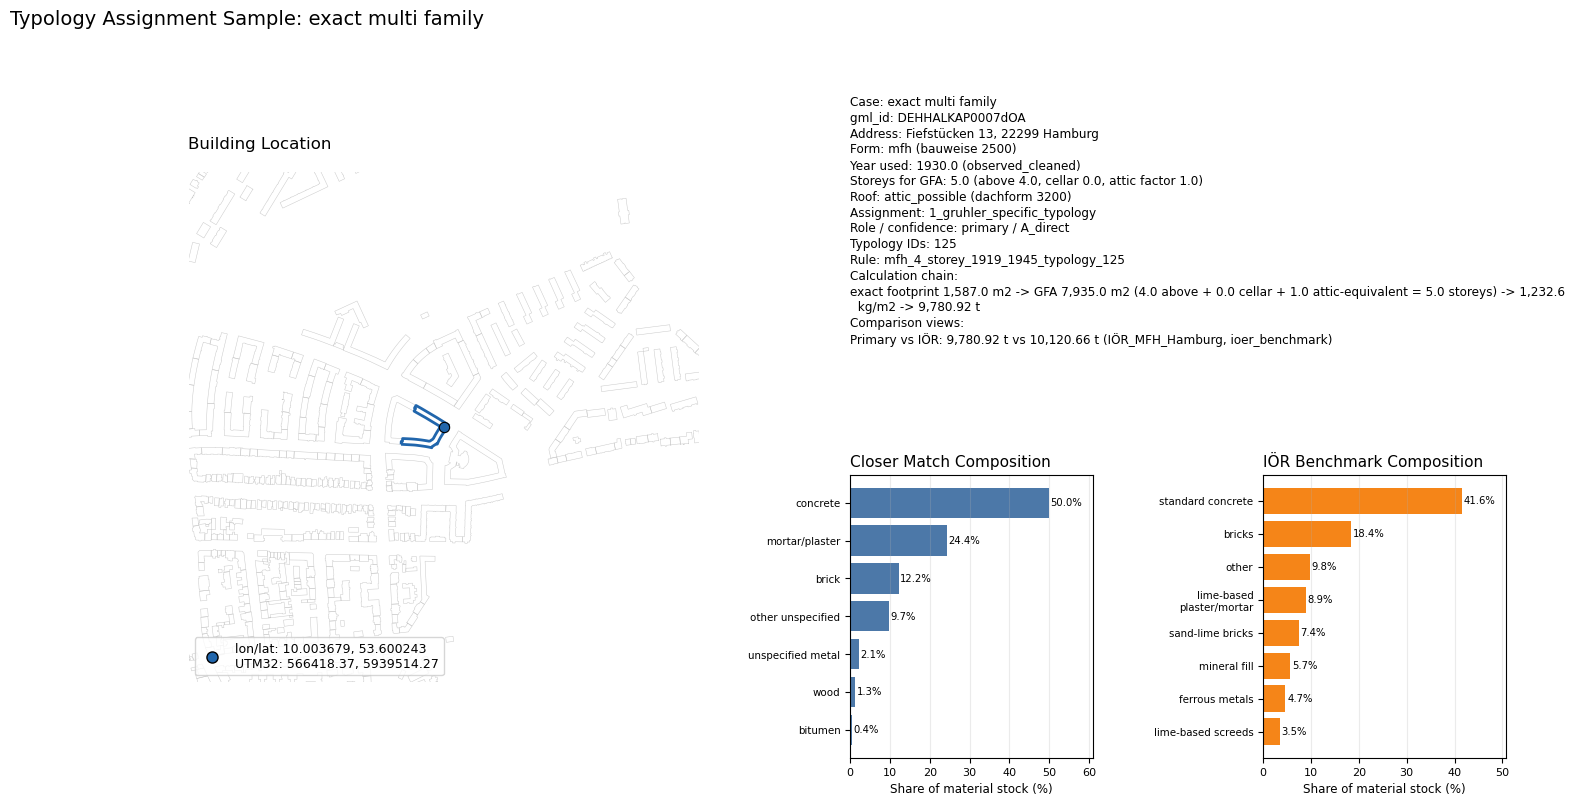

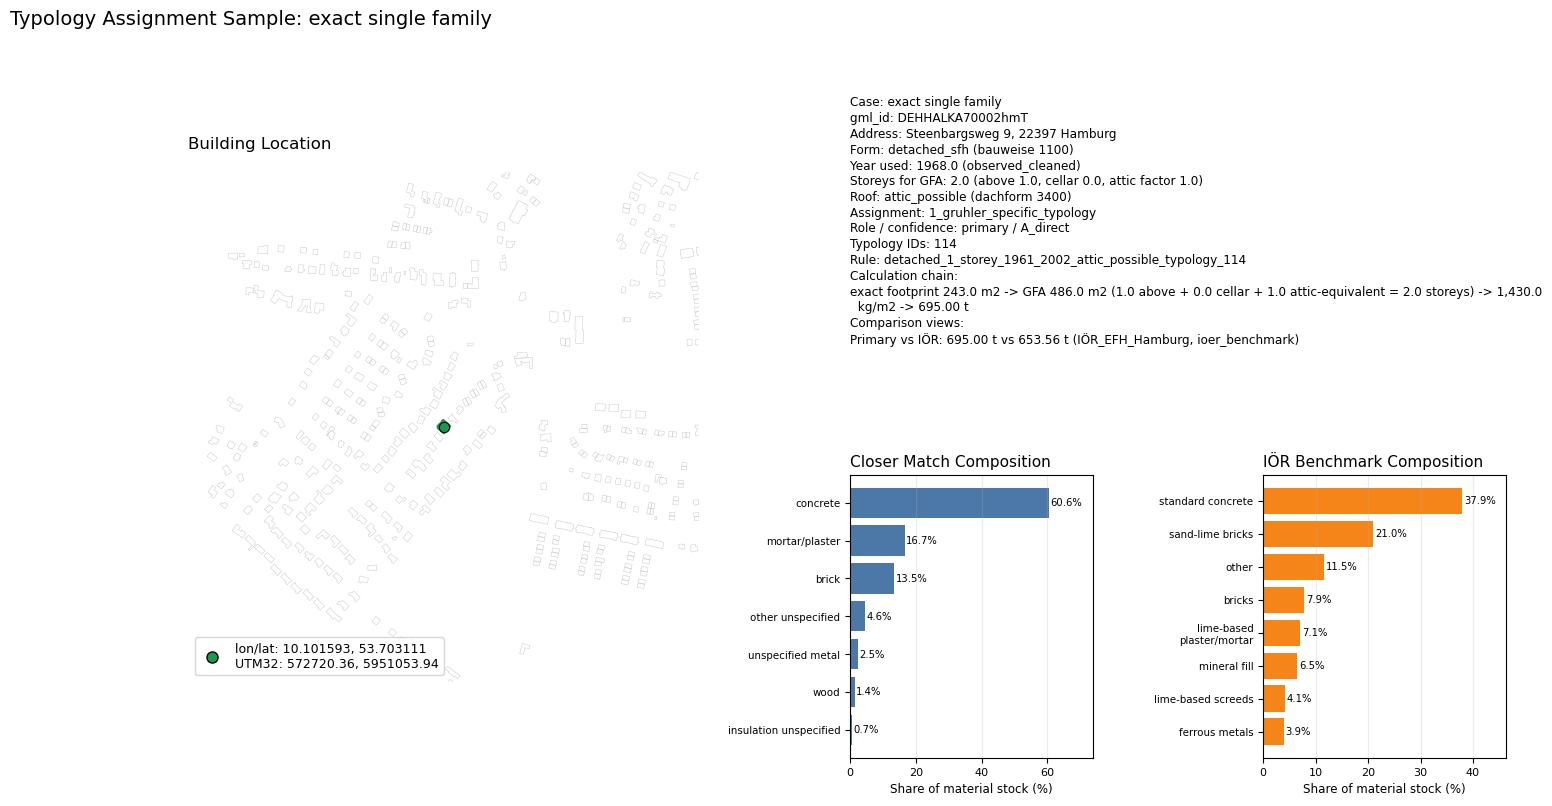

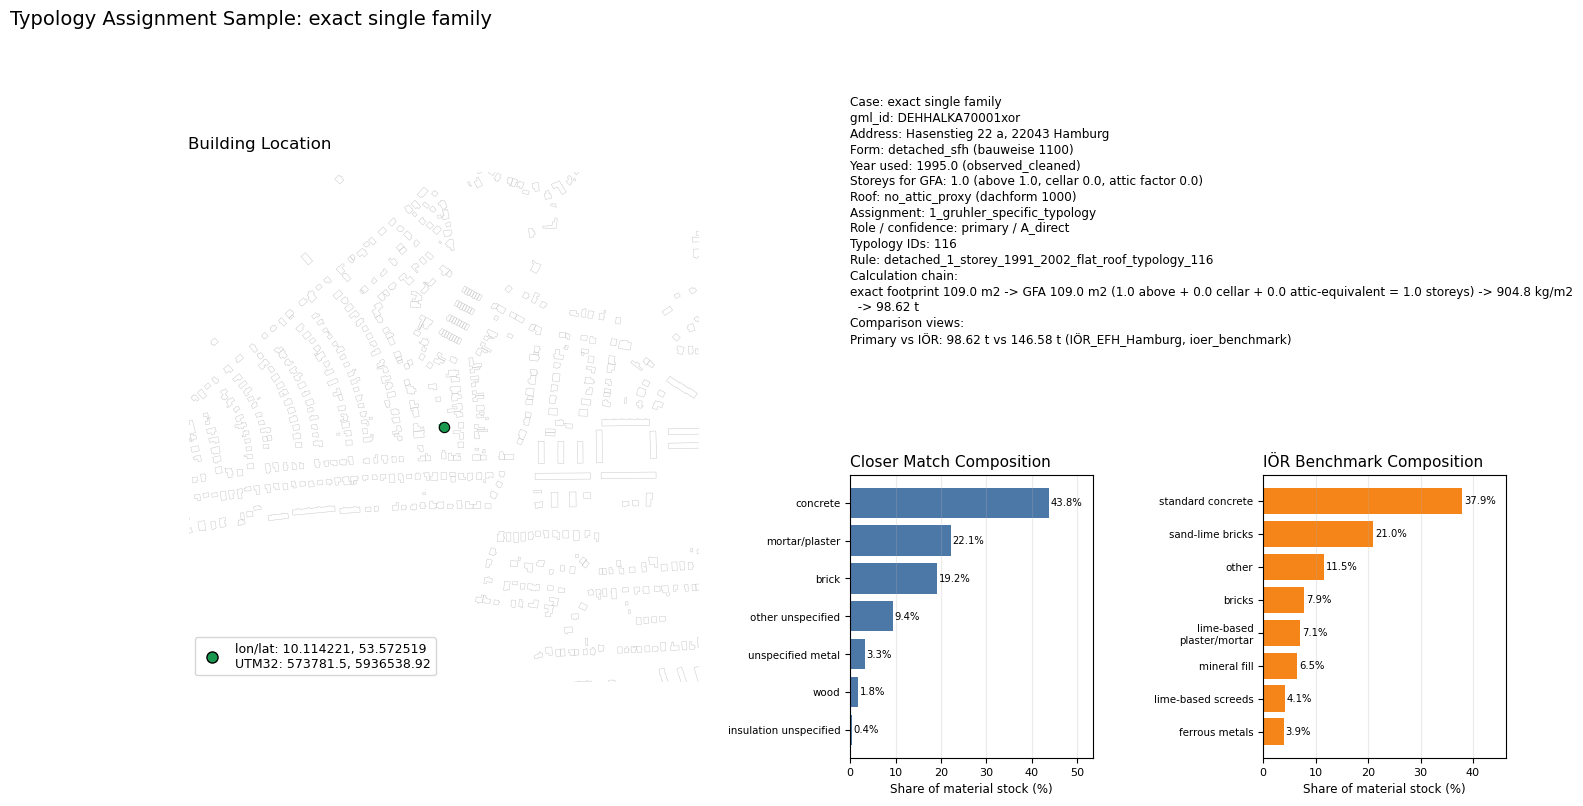

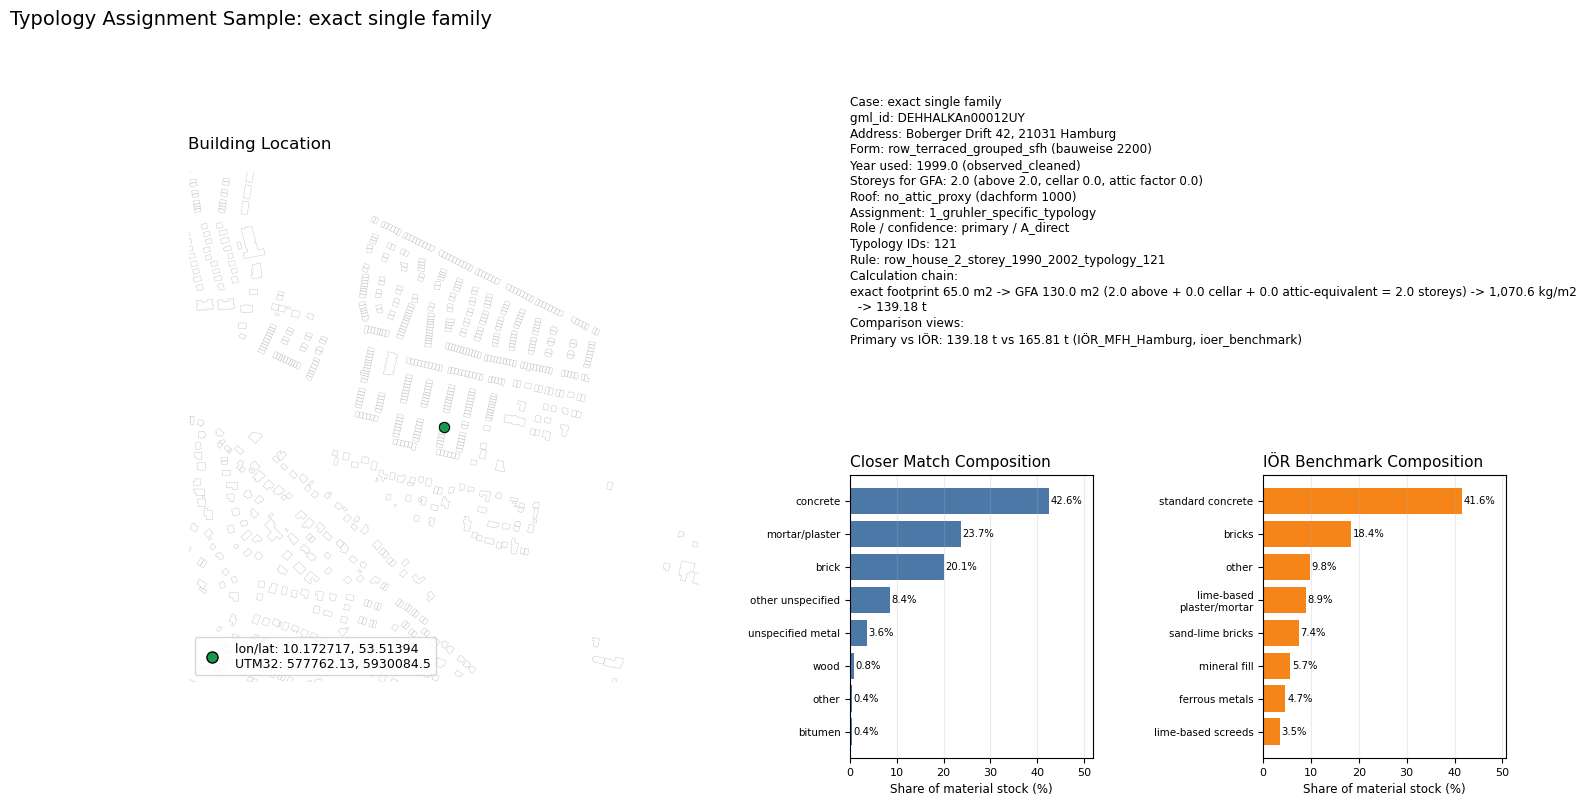

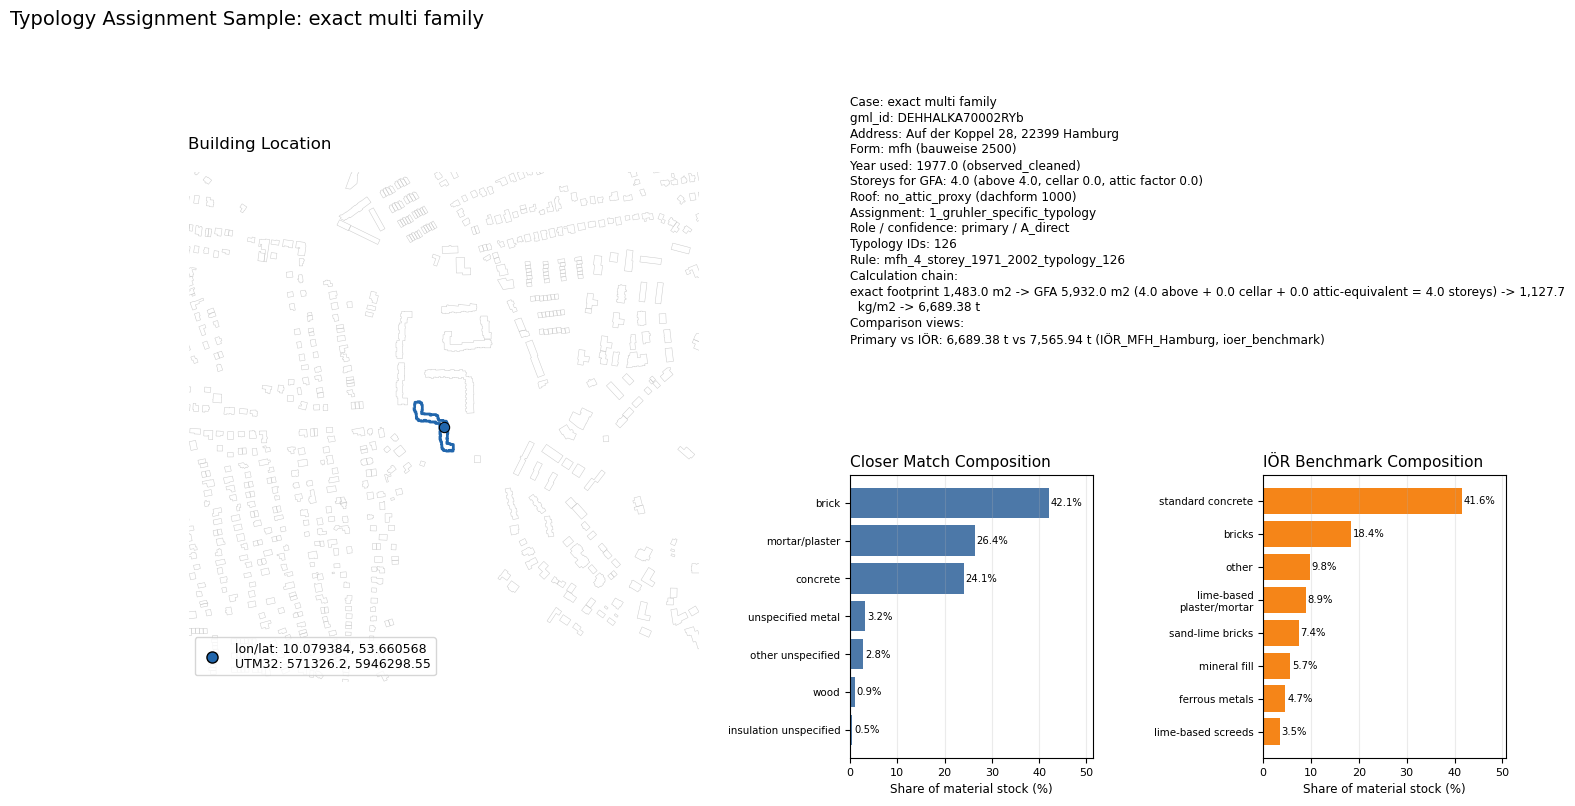

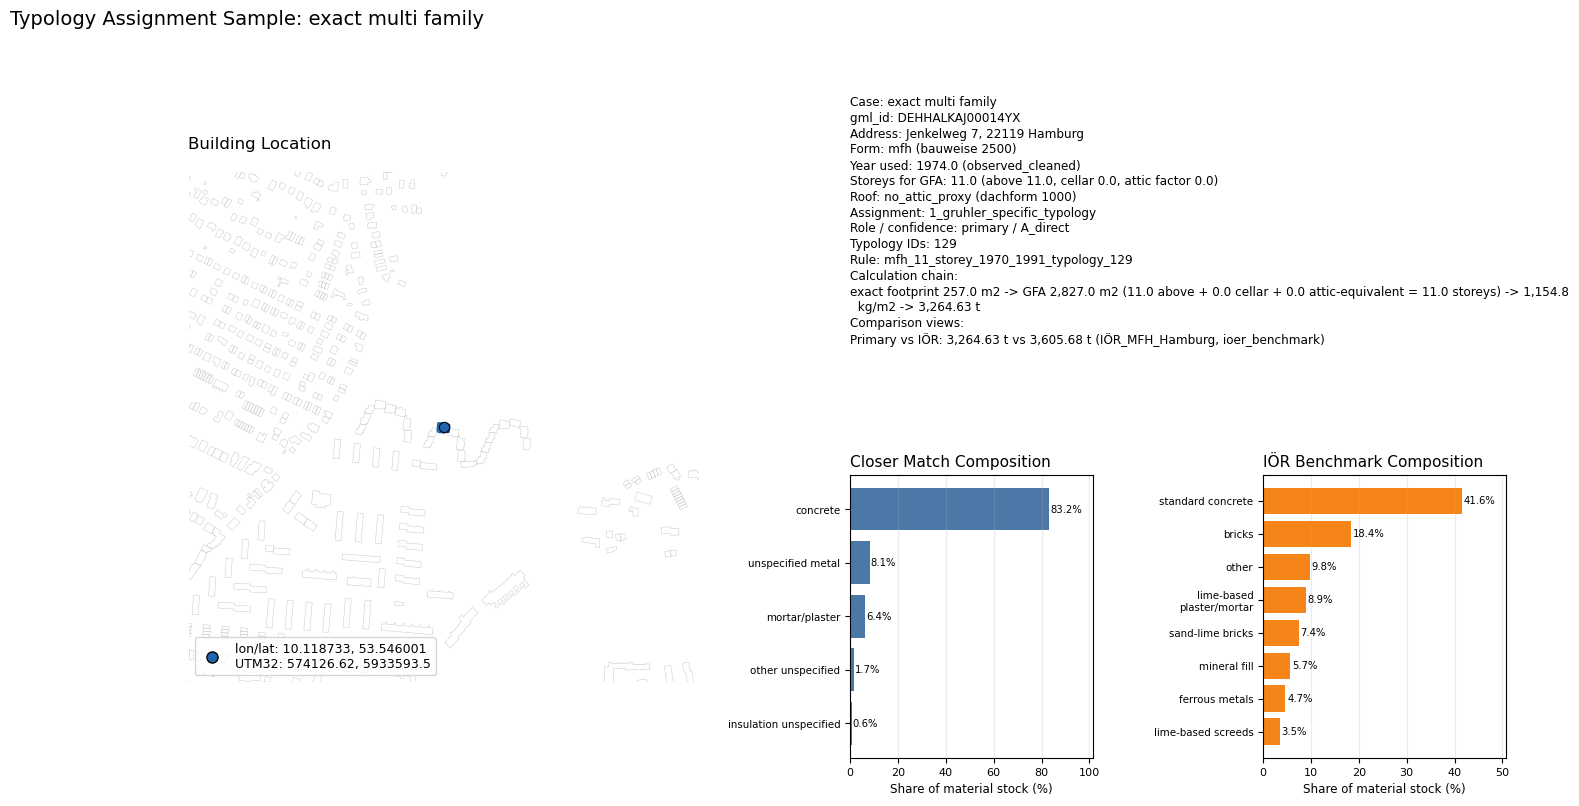

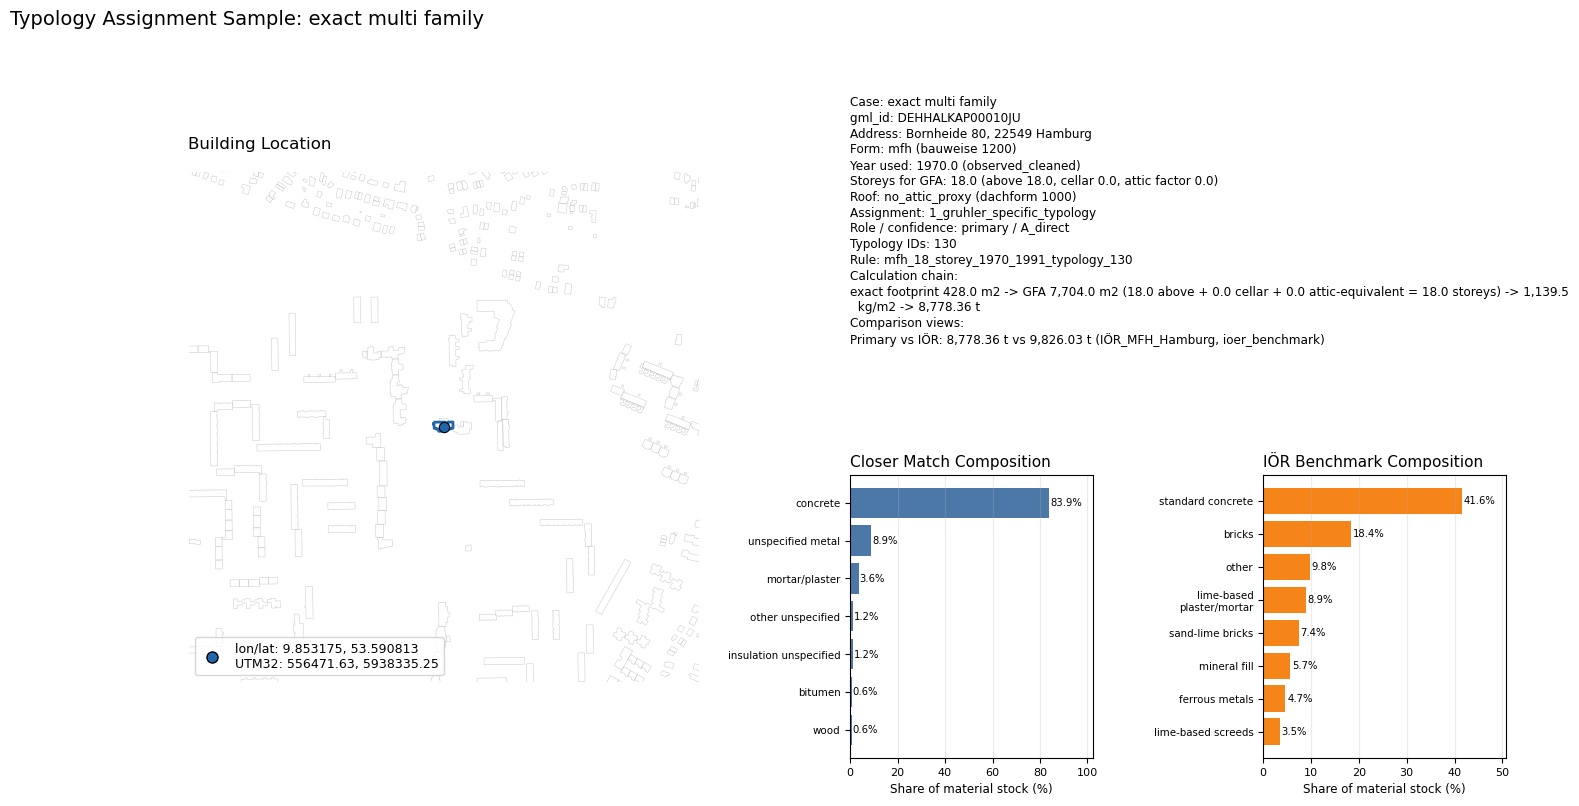

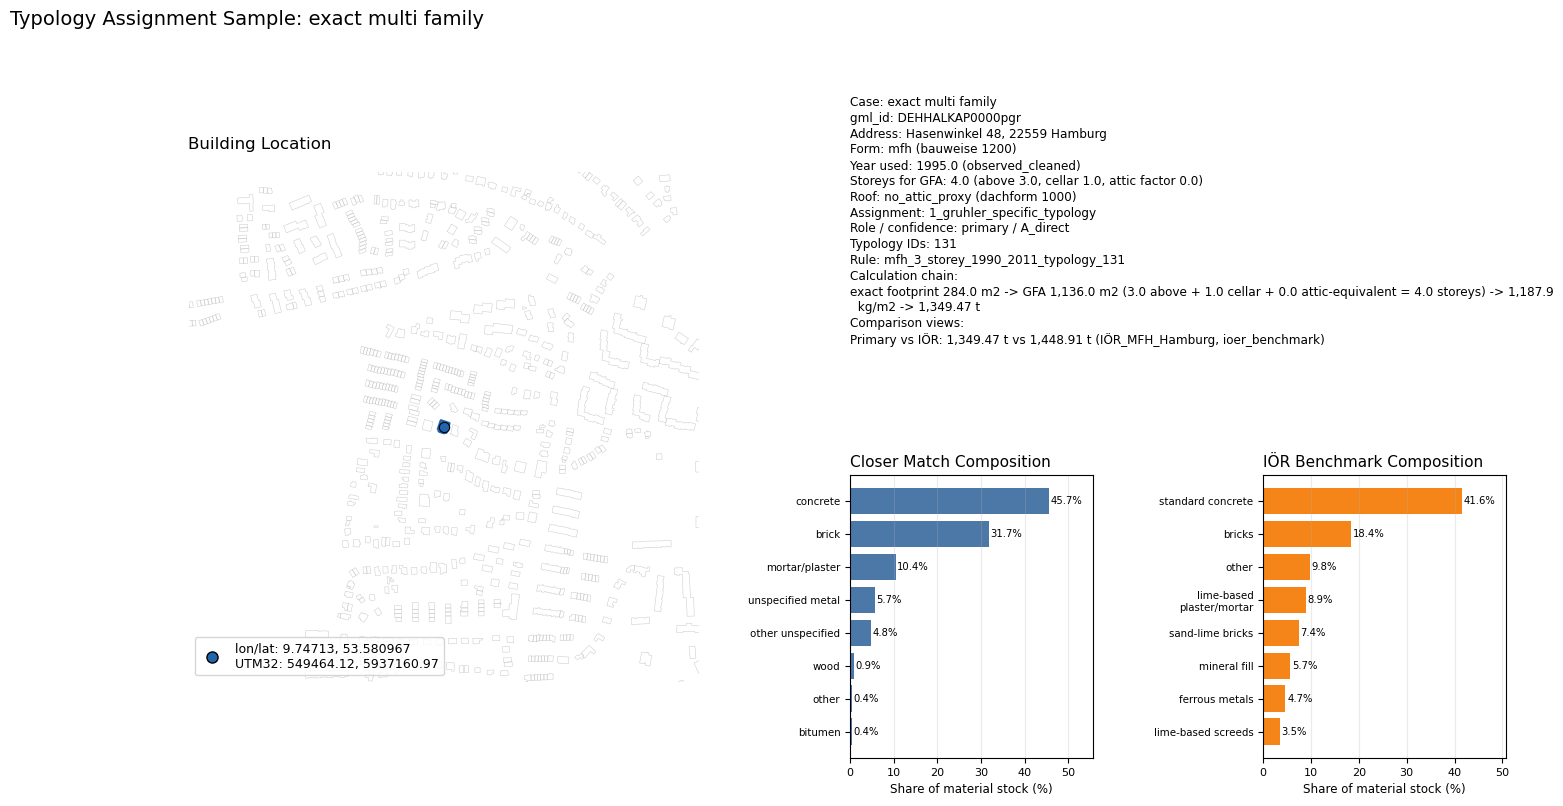

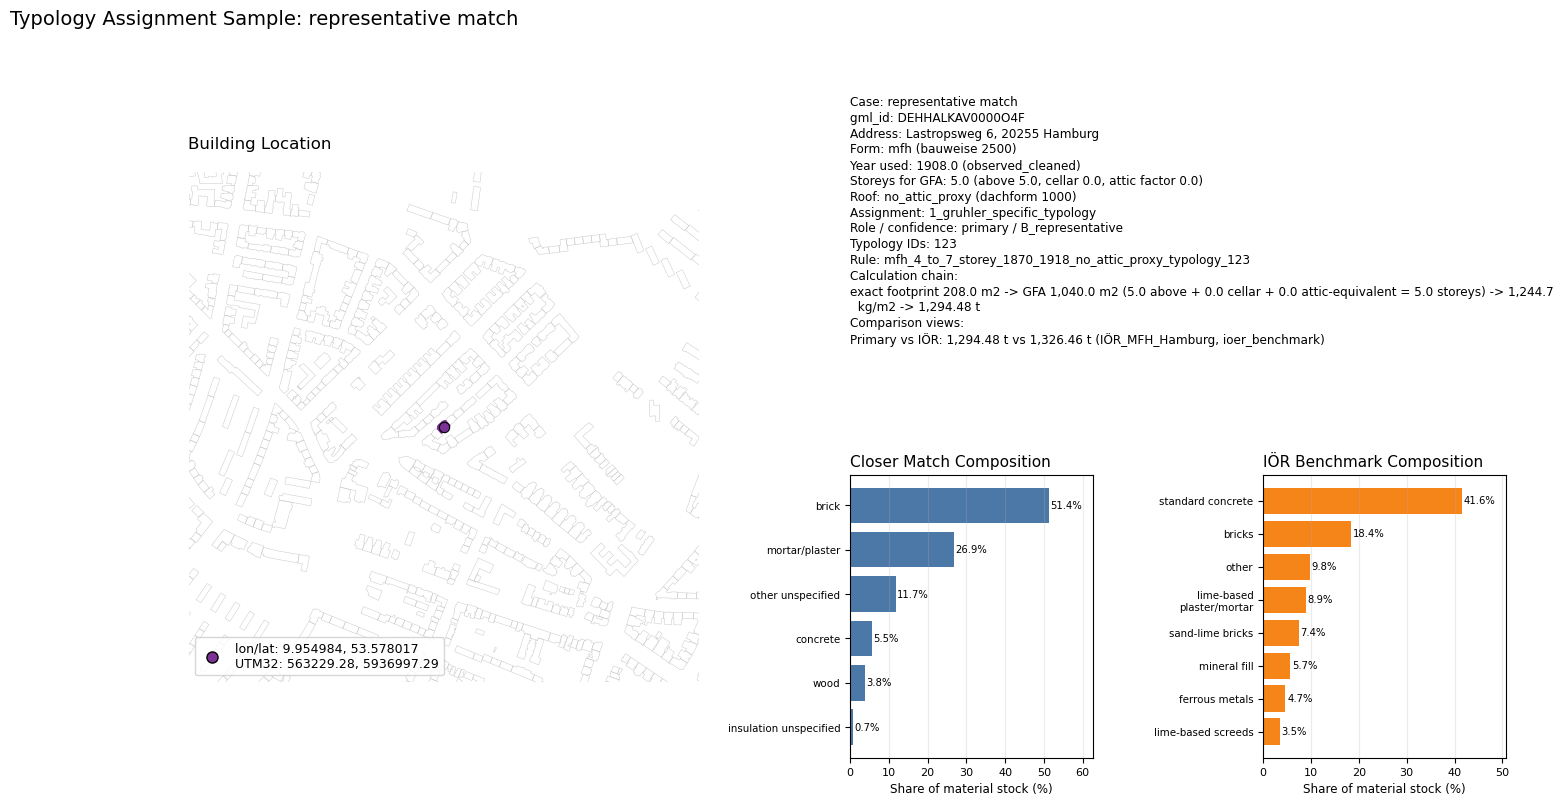

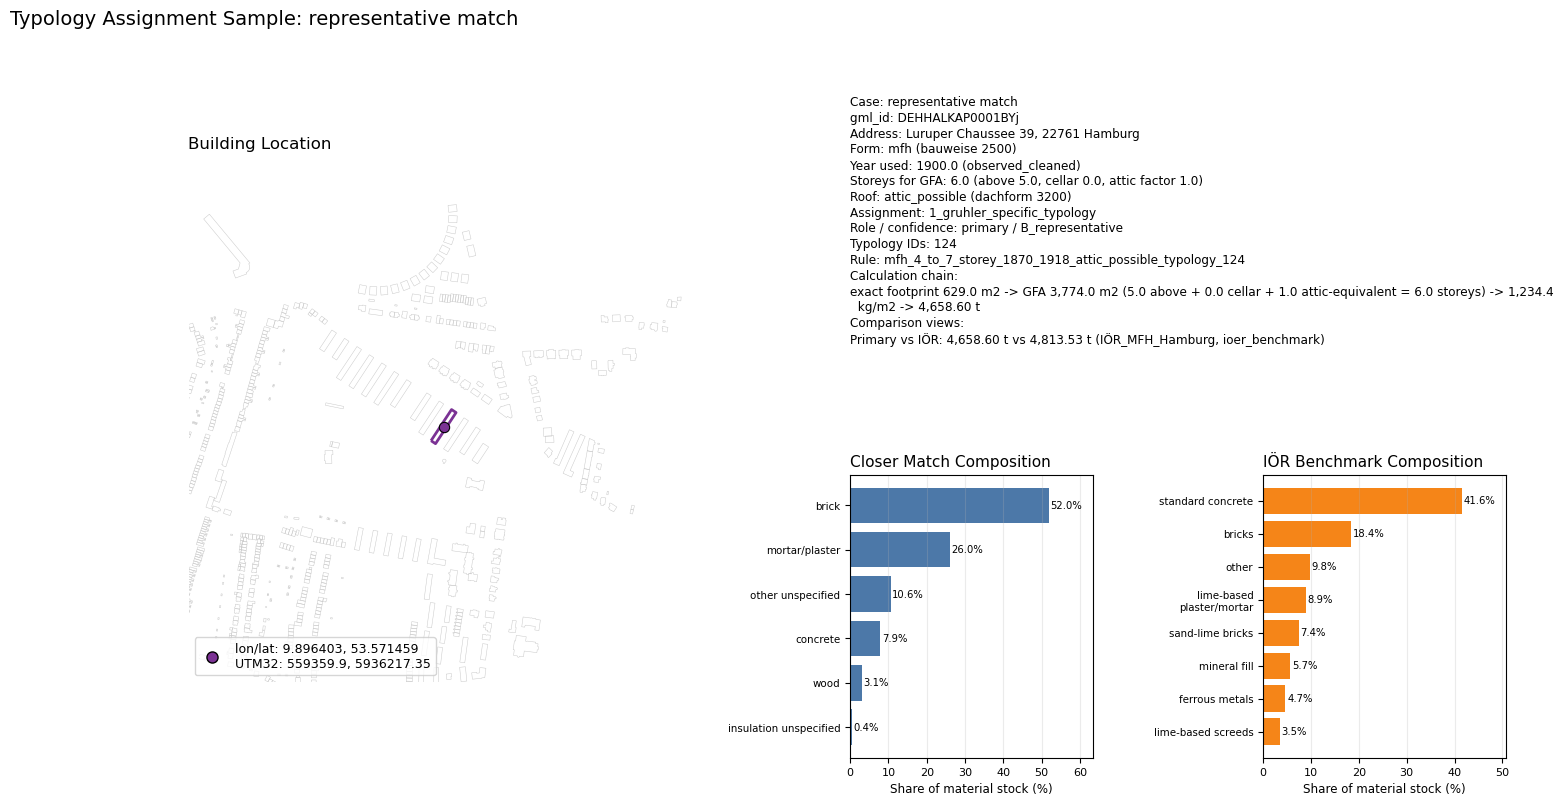

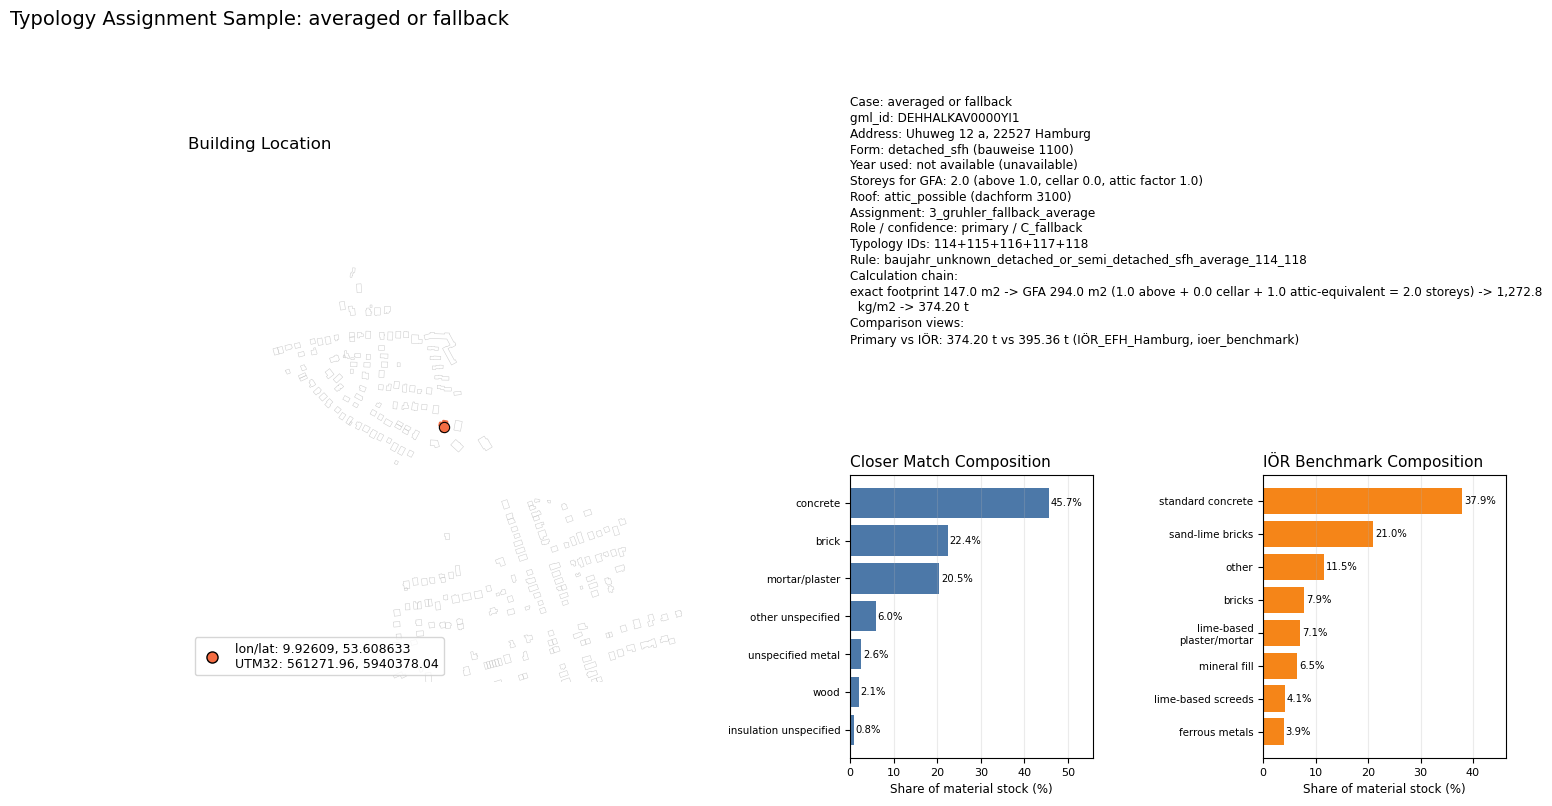

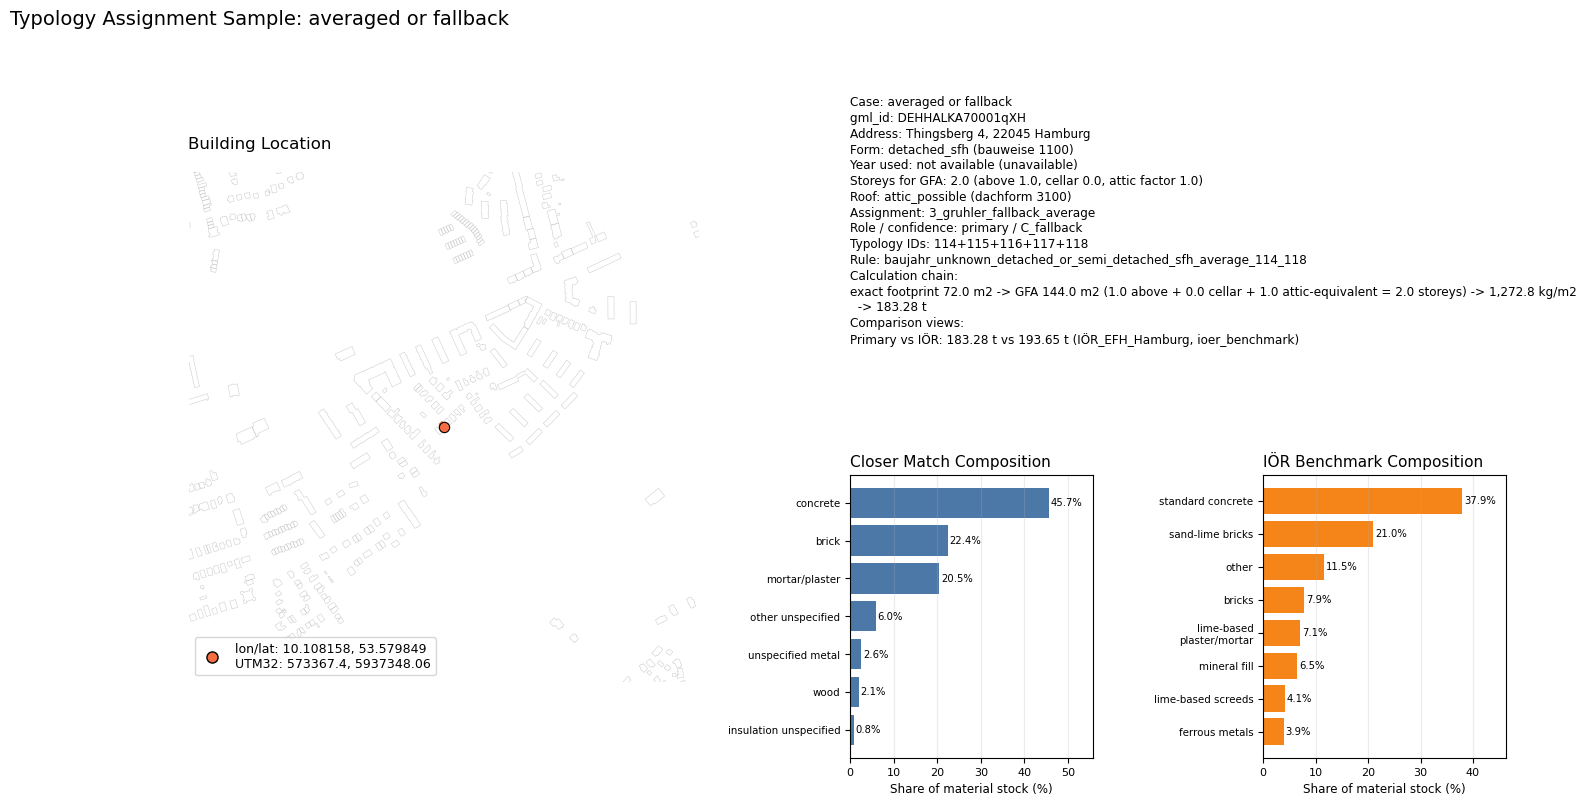

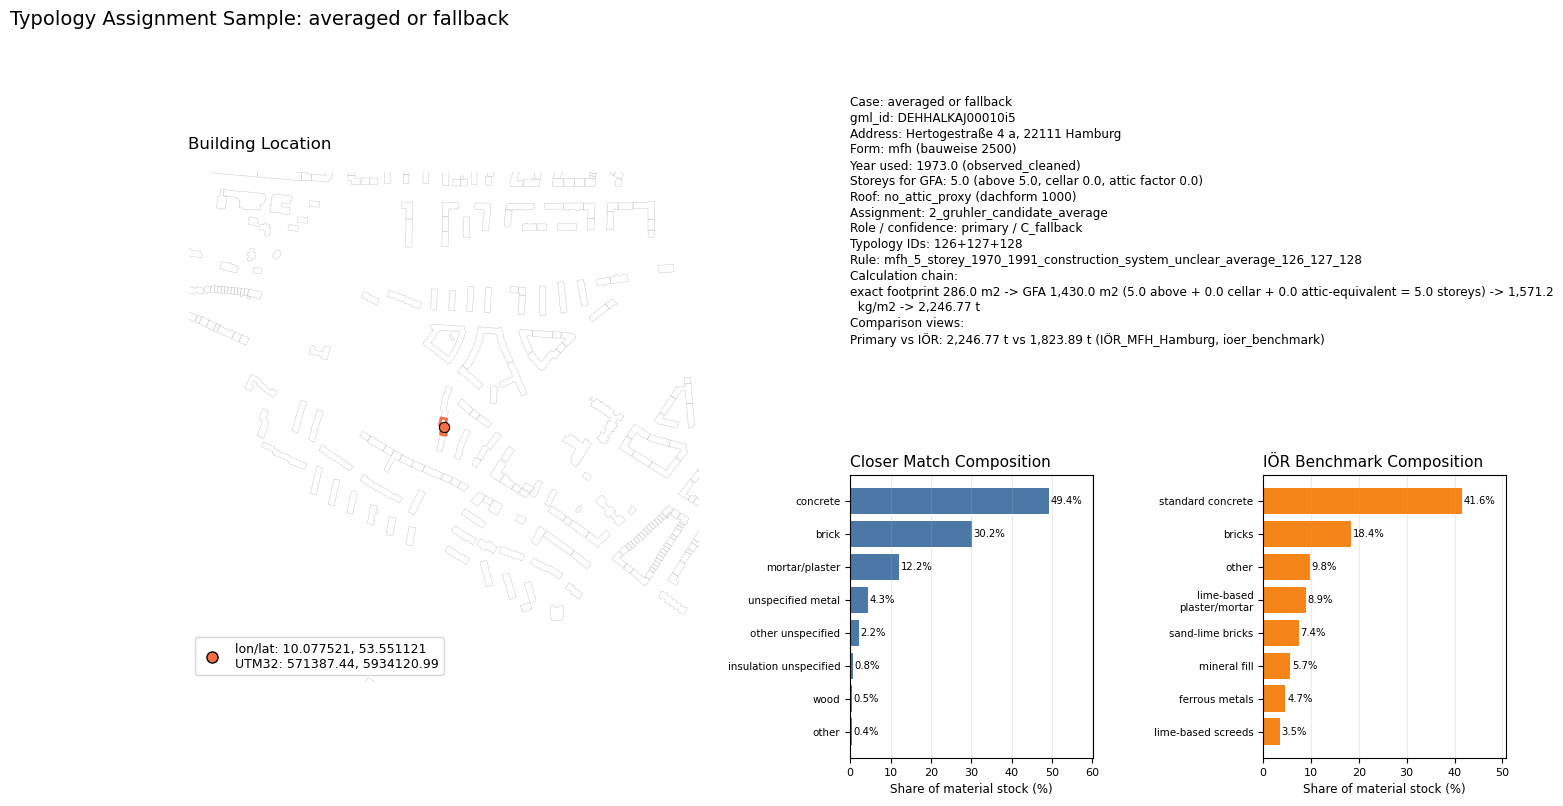

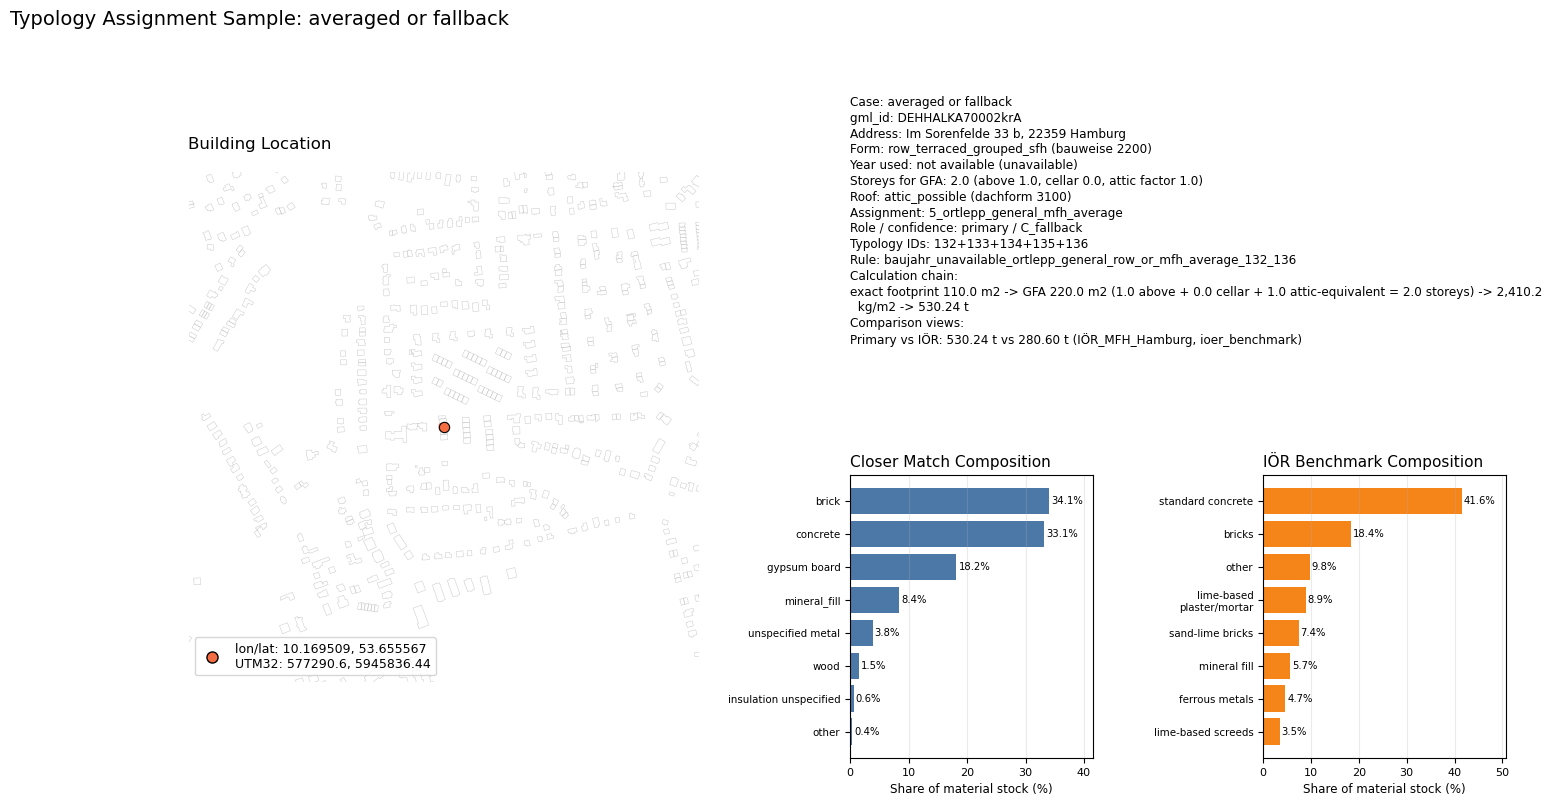

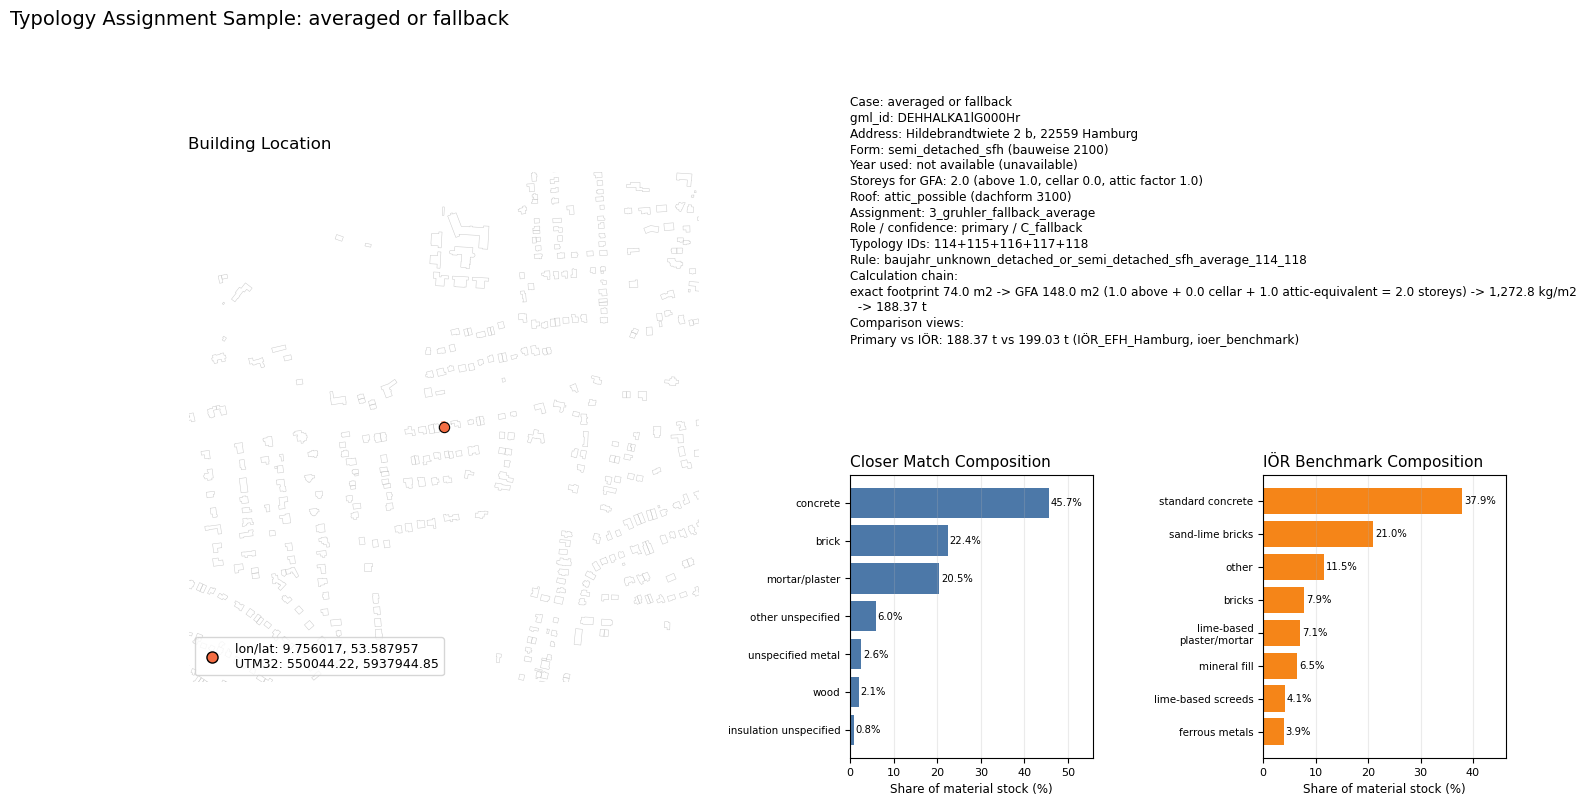

Individual dashboard directory: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/results/maps/hamburg_heeren_individual_sample_dashboards
/Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/results/maps/hamburg_heeren_individual_sample_dashboards/sample_01_exact_multi_family_DEHHALKAP0007dOA.png
/Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/results/maps/hamburg_heeren_individual_sample_dashboards/sample_02_exact_single_family_DEHHALKA70002hmT.png
/Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/results/maps/hamburg_heeren_individual_sample_dashboards/sample_03_exact_single_family_DEHHALKA70001xor.png
/Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/results/maps/hamburg_heeren_individual_sample_dashboards/sample_04_exact_single_family_DEHHALKAn00012UY.png
/Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/results/maps/hamburg_heeren_individual_sample_dashboards/sample_05_exact_multi_family_DEHHALKA70002RYb.png
/Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/results/maps/ham

In [4]:
dashboard_colors = {
    "exact_single_family": "#1a9850",
    "exact_multi_family": "#2166ac",
    "representative_match": "#7b3294",
    "averaged_or_fallback": "#f46d43",
}

material_display_names = {
    "paper_cardboard": "paper/cardboard",
    "mortar_plaster": "mortar/plaster",
    "plaster_board_gypsum": "gypsum board",
    "natural_stone": "natural stone",
    "cement_asbestos": "cement asbestos",
    "siding_unspecified": "siding unspecified",
    "insulation_unspecified": "insulation unspecified",
    "other_unspecified_material": "other unspecified",
    "unspecified_metal": "unspecified metal",
}


ioer_material_display_names = {
    "Standardbeton": "standard concrete",
    "Leichtbeton": "lightweight concrete",
    "Ziegelsteine": "bricks",
    "Ziegelsteine mit Dämmung": "insulated bricks",
    "Ziegeldeckung": "clay roof tiles",
    "Kalkhaltige Putze, Mörtel": "lime-based plaster/mortar",
    "Gips-/anhydrithaltige Putze, Mörtel": "gypsum/anhydrite plaster/mortar",
    "Ton-/lehmhaltige Putze, Mörtel": "clay-based plaster/mortar",
    "Putze, Mörtel mit synthetischen Anteilen": "plaster/mortar with synthetics",
    "Kalkhaltige Estriche": "lime-based screeds",
    "Gips-/anhydrithaltige Estriche": "gypsum/anhydrite screeds",
    "Trockenestrich (gips-/anhydrithaltig)": "dry screed, gypsum/anhydrite",
    "Estriche mit synthetischen Anteilen": "screeds with synthetics",
    "Kalksandsteine": "sand-lime bricks",
    "Porenbetonsteine": "aerated concrete blocks",
    "Betonsteine": "concrete blocks",
    "Lehmsteine": "adobe/clay blocks",
    "Gips-/Gipskartonplatten": "gypsum/plasterboard panels",
    "Mineralische Bauplatten": "mineral building boards",
    "Mineralische Wärmedämmstoffe": "mineral insulation",
    "Betondachsteindeckung": "concrete roof tiles",
    "Faserzementdeckung": "fiber-cement roofing",
    "Schieferdeckung": "slate roofing",
    "Substratschicht (\"Gründach\")": "green-roof substrate",
    "Mineralische Schüttungen": "mineral fill",
    "Glas": "glass",
    "Natursteine": "natural stone",
    "Sonstige mineralische Baustoffe": "other mineral materials",
    "Schnittholz": "sawn timber",
    "Verarbeitetes Holz": "engineered wood",
    "Nachwachsende Wärmedämmstoffe": "bio-based insulation",
    "Stroh-/Schilfdeckung": "straw/reed roofing",
    "Sonstige Materialien (nicht mineralisch)": "other non-mineral materials",
    "Erdölbasierte Wärmedämmstoffe": "petroleum-based insulation",
    "Kunststoffdachdeckung": "plastic roofing",
    "Erdölbasierte Beläge, Abdichtungen": "petroleum-based coverings/seals",
    "Bitumendachdeckung": "bitumen roofing",
    "Bitumenhaltige Beläge, Abdichtungen": "bituminous coverings/seals",
    "Metalldachdeckung": "metal roofing",
    "Eisenmetalle": "ferrous metals",
    "Aluminiumhaltige Beläge, Abdichtungen": "aluminium-based coverings/seals",
    "Aluminium": "aluminium",
    "Kupfer": "copper",
    "Sonstige Nichteisenmetalle": "other non-ferrous metals",
}


def clean_label(value):
    if pd.isna(value) or str(value).strip() == "":
        return "not available"
    return str(value)


def format_number(value, decimals=1):
    numeric = pd.to_numeric(value, errors="coerce")
    if pd.isna(numeric):
        return "n/a"
    return f"{numeric:,.{decimals}f}"


def calculation_chain(row):
    footprint = format_number(row.get("grundflaeche_clean_m2"), 1)
    gfa = format_number(row.get("estimated_gfa_m2"), 1)
    total_intensity = format_number(row.get("total_material_intensity_kg_m2"), 1)
    total_stock = format_number(row.get("total_material_stock_t"), 2)
    above = format_number(row.get("above_ground_storeys_clean"), 1)
    cellar = format_number(row.get("underground_storeys_for_gfa"), 1)
    attic = format_number(row.get("attic_storey_factor_for_gfa"), 1)
    total_storeys = format_number(row.get("total_storeys_for_gfa"), 1)
    storey_chain = f"{above} above + {cellar} cellar + {attic} attic-equivalent = {total_storeys} storeys"
    return f"exact footprint {footprint} m2 -> GFA {gfa} m2 ({storey_chain}) -> {total_intensity} kg/m2 -> {total_stock} t"


def comparison_chain(row):
    lines = []
    primary = format_number(row.get("total_material_stock_t"), 2)
    if pd.notna(row.get("ioer_total_material_stock_t")):
        ioer = format_number(row.get("ioer_total_material_stock_t"), 2)
        lines.append(f"Primary vs IÖR: {primary} t vs {ioer} t ({clean_label(row.get('ioer_variant_type'))}, {clean_label(row.get('benchmark_role'))})")
    else:
        lines.append("Primary vs IÖR: no IÖR benchmark result")
    return lines


def quality_tags(row):
    tags = []
    if pd.notna(row.get("confidence_label")) and str(row.get("confidence_label")).strip():
        tags.append(str(row.get("confidence_label")))
    elif pd.notna(row.get("confidence_tier")) and str(row.get("confidence_tier")).strip():
        tags.append(str(row.get("confidence_tier")))
    if pd.notna(row.get("assignment_reference_kind")) and str(row.get("assignment_reference_kind")).strip():
        tags.append(str(row.get("assignment_reference_kind")))
    for flag in str(row.get("quality_flags", "")).split(";"):
        flag = flag.strip()
        if flag:
            tags.append(flag)
    return tags if tags else ["no quality flags recorded"]


def compact_material_label(label, width=22):
    return "\n".join(textwrap.wrap(str(label), width=width, break_long_words=False))


def composition_from_columns(row, columns, label_from_column, top_n=7):
    records = []
    for column in columns:
        value = pd.to_numeric(row.get(column), errors="coerce")
        if pd.notna(value) and value > 0:
            records.append({"material": label_from_column(column), "stock_t": float(value)})
    composition = pd.DataFrame(records)
    if composition.empty:
        return composition
    composition = composition.sort_values("stock_t", ascending=False)
    if len(composition) > top_n:
        top = composition.head(top_n).copy()
        other_stock = composition.iloc[top_n:]["stock_t"].sum()
        composition = pd.concat([top, pd.DataFrame([{"material": "other", "stock_t": other_stock}])], ignore_index=True)
    total = composition["stock_t"].sum()
    composition["share_pct"] = composition["stock_t"] / total * 100 if total > 0 else 0
    composition["material_label"] = composition["material"].map(compact_material_label)
    return composition


def material_composition_for_row(row, top_n=7):
    def label_from_column(column):
        material = column.replace("_stock_t", "")
        return material_display_names.get(material, material)
    return composition_from_columns(row, stock_t_columns, label_from_column, top_n=top_n)


def ioer_material_composition_for_row(row, top_n=7):
    def label_from_column(column):
        group_id = column.replace("ioer_material_group_", "").replace("_stock_t", "")
        material = ioer_material_group_names.get(group_id, f"IÖR group {group_id}")
        return ioer_material_display_names.get(material, material)
    return composition_from_columns(row, ioer_stock_t_columns, label_from_column, top_n=top_n)


def draw_composition_axis(ax, composition, title, color, x_label=False):
    if composition.empty:
        ax.text(0.5, 0.5, "No positive material stock values", ha="center", va="center", fontsize=8.5)
        ax.axis("off")
        ax.set_title(title, loc="left", fontsize=11)
        return
    composition = composition.sort_values("share_pct", ascending=True)
    ax.barh(composition["material_label"], composition["share_pct"], color=color)
    ax.set_title(title, loc="left", fontsize=11)
    ax.grid(axis="x", alpha=0.25)
    ax.tick_params(axis="y", labelsize=7.4)
    ax.tick_params(axis="x", labelsize=8)
    if x_label:
        ax.set_xlabel("Share of material stock (%)", fontsize=8.5)
    for y_pos, (_, rec) in enumerate(composition.iterrows()):
        ax.text(rec["share_pct"] + 0.35, y_pos, f"{rec['share_pct']:.1f}%", va="center", fontsize=7.2)
    ax.set_xlim(0, max(10, composition["share_pct"].max() * 1.22))


def wrap_info_line(line, width=118):
    if len(str(line)) <= width:
        return str(line)
    return textwrap.fill(str(line), width=width, subsequent_indent="  ")


def draw_individual_dashboard(row, context_gdf, output_path):
    color = dashboard_colors.get(row["sample_case"], "#666666")
    point = row.geometry.representative_point()
    x, y = point.x, point.y
    buffer_m = 450
    context = context_gdf.cx[x - buffer_m:x + buffer_m, y - buffer_m:y + buffer_m]
    if context.empty:
        context = context_gdf

    composition = material_composition_for_row(row)
    ioer_composition = ioer_material_composition_for_row(row)
    fig = plt.figure(figsize=(17, 8.6))
    gs = fig.add_gridspec(2, 2, width_ratios=[1.05, 1.35], height_ratios=[1, 1], hspace=0.34, wspace=0.26)

    ax_map = fig.add_subplot(gs[:, 0])
    context.boundary.plot(ax=ax_map, color="#c9c9c9", linewidth=0.35)
    gpd.GeoSeries([row.geometry], crs=context_gdf.crs).boundary.plot(ax=ax_map, color=color, linewidth=2.0)
    ax_map.scatter([x], [y], s=55, color=color, edgecolor="black", linewidth=0.8, zorder=5)
    ax_map.set_xlim(x - buffer_m, x + buffer_m)
    ax_map.set_ylim(y - buffer_m, y + buffer_m)
    ax_map.set_aspect("equal")
    ax_map.set_axis_off()
    ax_map.set_title("Building Location", loc="left", fontsize=12)
    ax_map.legend(
        handles=[plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color, markeredgecolor="black", markersize=8,
                            label=f"lon/lat: {row['longitude']}, {row['latitude']}\nUTM32: {row['centroid_x_25832']}, {row['centroid_y_25832']}")],
        loc="lower left",
        frameon=True,
        fontsize=9,
    )

    ax_info = fig.add_subplot(gs[0, 1])
    ax_info.axis("off")
    info_lines = [
        f"Case: {row['sample_case'].replace('_', ' ')}",
        f"gml_id: {row['gml_id']}",
        f"Address: {row['address']}",
        f"Form: {row['bauweise_group']} (bauweise {clean_label(row.get('bauweise'))})",
        f"Year used: {clean_label(row.get('construction_year_used_for_assignment'))} ({clean_label(row.get('construction_year_assignment_source'))})",
        f"Storeys for GFA: {clean_label(row.get('total_storeys_for_gfa'))} (above {clean_label(row.get('above_ground_storeys_clean'))}, cellar {clean_label(row.get('underground_storeys_for_gfa'))}, attic factor {clean_label(row.get('attic_storey_factor_for_gfa'))})",
        f"Roof: {clean_label(row.get('roof_group_csv'))} (dachform {clean_label(row.get('dachform'))})",
        f"Assignment: {row['assignment_level']}",
        f"Role / confidence: {clean_label(row.get('assignment_role'))} / {clean_label(row.get('confidence_tier'))}",
        f"Typology IDs: {row['assigned_typology_ids']}",
        f"Rule: {row['typology_assignment_rule']}",
        "Calculation chain:",
        calculation_chain(row),
        "Comparison views:",
        *comparison_chain(row),
    ]
    ax_info.text(0, 1, "\n".join(wrap_info_line(line) for line in info_lines), va="top", ha="left", fontsize=8.7, linespacing=1.28)

    comp_gs = gs[1, 1].subgridspec(1, 2, wspace=0.7)
    ax_primary_comp = fig.add_subplot(comp_gs[0, 0])
    ax_ioer_comp = fig.add_subplot(comp_gs[0, 1])
    draw_composition_axis(ax_primary_comp, composition, "Closer Match Composition", "#4c78a8", x_label=True)
    draw_composition_axis(ax_ioer_comp, ioer_composition, "IÖR Benchmark Composition", "#f58518", x_label=True)

    fig.suptitle(f"Typology Assignment Sample: {row['sample_case'].replace('_', ' ')}", fontsize=14, x=0.02, ha="left")
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


sample_gdf["dashboard_color"] = sample_gdf["sample_case"].map(dashboard_colors).fillna("#666666")
for _, row in sample_gdf.iterrows():
    draw_individual_dashboard(row, gdf, row["dashboard_png"])

print("Individual dashboard directory:", SAMPLE_DASHBOARD_DIR)
for path in sample_gdf["dashboard_png"]:
    print(path)


In [5]:
display_columns = [
    "sample_case",
    "gml_id",
    "longitude",
    "latitude",
    "address",
    "dashboard_png",
    "bauweise_group",
    "baujahr",
    "construction_year_used_for_assignment",
    "roof_group_csv",
    "grundflaeche_clean_m2",
    "above_ground_storeys_clean",
    "underground_storeys_for_gfa",
    "attic_storey_factor_for_gfa",
    "total_storeys_for_gfa",
    "estimated_gfa_m2",
    "total_material_intensity_kg_m2",
    "assignment_level",
    "confidence_label",
    "assigned_typology_ids",
    "assignment_reference_kind",
    "typology_assignment_rule",
    "total_material_stock_t",
    "ioer_variant_type",
    "ioer_variant_assignment_role",
    "benchmark_role",
    "ioer_variant_confidence",
    "ioer_total_material_stock_t",
]
display_columns = [column for column in display_columns if column in sample_table.columns]
sample_table[display_columns]

,sample_case,gml_id,longitude,latitude,address,dashboard_png,bauweise_group,baujahr,construction_year_used_for_assignment,roof_group_csv,grundflaeche_clean_m2,above_ground_storeys_clean,underground_storeys_for_gfa,attic_storey_factor_for_gfa,total_storeys_for_gfa,estimated_gfa_m2,total_material_intensity_kg_m2,assignment_level,confidence_label,assigned_typology_ids,assignment_reference_kind,typology_assignment_rule,total_material_stock_t,ioer_variant_type,ioer_variant_assignment_role,benchmark_role,ioer_variant_confidence,ioer_total_material_stock_t
0,exact_multi_family,DEHHALKAP0007dOA,10.003679,53.600243,"Fiefstücken 13, 22299 Hamburg",/Users/rirarum/Documents/REAP/Thesis/URBAN MIN...,mfh,1930,1930.0,attic_possible,1587.0,4.0,0.0,1.0,5.0,7935.0,1232.63,1_gruhler_specific_typology,A - Direct match,125,single_typology,mfh_4_storey_1919_1945_typology_125,9780.92,IÖR_MFH_Hamburg,benchmark,ioer_benchmark,,10120.66
1,exact_single_family,DEHHALKA70002hmT,10.101593,53.703111,"Steenbargsweg 9, 22397 Hamburg",/Users/rirarum/Documents/REAP/Thesis/URBAN MIN...,detached_sfh,1968,1968.0,attic_possible,243.0,1.0,0.0,1.0,2.0,486.0,1430.05,1_gruhler_specific_typology,A - Direct match,114,single_typology,detached_1_storey_1961_2002_attic_possible_typ...,695.00,IÖR_EFH_Hamburg,benchmark,ioer_benchmark,,653.56
2,exact_single_family,DEHHALKA70001xor,10.114221,53.572519,"Hasenstieg 22 a, 22043 Hamburg",/Users/rirarum/Documents/REAP/Thesis/URBAN MIN...,detached_sfh,1995,1995.0,no_attic_proxy,109.0,1.0,0.0,0.0,1.0,109.0,904.77,1_gruhler_specific_typology,A - Direct match,116,single_typology,detached_1_storey_1991_2002_flat_roof_typology...,98.62,IÖR_EFH_Hamburg,benchmark,ioer_benchmark,,146.58
3,exact_single_family,DEHHALKAn00012UY,10.172717,53.513940,"Boberger Drift 42, 21031 Hamburg",/Users/rirarum/Documents/REAP/Thesis/URBAN MIN...,row_terraced_grouped_sfh,1999,1999.0,no_attic_proxy,65.0,2.0,0.0,0.0,2.0,130.0,1070.58,1_gruhler_specific_typology,A - Direct match,121,single_typology,row_house_2_storey_1990_2002_typology_121,139.18,IÖR_MFH_Hamburg,benchmark,ioer_benchmark,,165.81
4,exact_multi_family,DEHHALKA70002RYb,10.079384,53.660568,"Auf der Koppel 28, 22399 Hamburg",/Users/rirarum/Documents/REAP/Thesis/URBAN MIN...,mfh,1977,1977.0,no_attic_proxy,1483.0,4.0,0.0,0.0,4.0,5932.0,1127.68,1_gruhler_specific_typology,A - Direct match,126,single_typology,mfh_4_storey_1971_2002_typology_126,6689.38,IÖR_MFH_Hamburg,benchmark,ioer_benchmark,,7565.94
5,exact_multi_family,DEHHALKAJ00014YX,10.118733,53.546001,"Jenkelweg 7, 22119 Hamburg",/Users/rirarum/Documents/REAP/Thesis/URBAN MIN...,mfh,1974,1974.0,no_attic_proxy,257.0,11.0,0.0,0.0,11.0,2827.0,1154.80,1_gruhler_specific_typology,A - Direct match,129,single_typology,mfh_11_storey_1970_1991_typology_129,3264.63,IÖR_MFH_Hamburg,benchmark,ioer_benchmark,,3605.68
6,exact_multi_family,DEHHALKAP00010JU,9.853175,53.590813,"Bornheide 80, 22549 Hamburg",/Users/rirarum/Documents/REAP/Thesis/URBAN MIN...,mfh,1970,1970.0,no_attic_proxy,428.0,18.0,0.0,0.0,18.0,7704.0,1139.45,1_gruhler_specific_typology,A - Direct match,130,single_typology,mfh_18_storey_1970_1991_typology_130,8778.36,IÖR_MFH_Hamburg,benchmark,ioer_benchmark,,9826.03
7,exact_multi_family,DEHHALKAP0000pgr,9.747130,53.580967,"Hasenwinkel 48, 22559 Hamburg",/Users/rirarum/Documents/REAP/Thesis/URBAN MIN...,mfh,1995,1995.0,no_attic_proxy,284.0,3.0,1.0,0.0,4.0,1136.0,1187.91,1_gruhler_specific_typology,A - Direct match,131,single_typology,mfh_3_storey_1990_2011_typology_131,1349.47,IÖR_MFH_Hamburg,benchmark,ioer_benchmark,,1448.91
8,representative_match,DEHHALKAV0000O4F,9.954984,53.578017,"Lastropsweg 6, 20255 Hamburg",/Users/rirarum/Documents/REAP/Thesis/URBAN MIN...,mfh,1908,1908.0,no_attic_proxy,208.0,5.0,0.0,0.0,5.0,1040.0,1244.69,1_gruhler_specific_typology,B - Representative match,123,single_typology,mfh_4_to_7_storey_1870_1918_no_attic_proxy_typ...,1294.48,IÖR_MFH_Hamburg,benchmark,ioer_benchmark,,1326.46
9,representative_match,DEHHALKAP0001BYj,9.896

## Address Derivation

`data/raw/ALKIS_Adressen_HH_2026-07-03.zip` contains `Adressen.gml` address points in EPSG:25832 with street name, house number, postcode, place name, and point coordinates.

The notebook attaches the nearest address point to each sampled building and shows only the resulting address on the individual dashboards. Internally, the code still computes match distance/quality so the method can be audited if needed, but those details are not shown on the house dashboard.

In [6]:
address_status = pd.DataFrame([
    {
        "question": "Does the GML help?",
        "answer": "Yes. It contains address points with EPSG:25832 coordinates and address text fields.",
    },
    {
        "question": "Parsed address points",
        "answer": len(address_points),
    },
    {
        "question": "Join method used in this notebook",
        "answer": "Nearest address point to each sampled building representative point.",
    },
    {
        "question": "Caveat",
        "answer": "This is a proximity match, not a building-ID match. Use address_match_distance_m and address_match_quality for review.",
    },
    {
        "question": "CSV role",
        "answer": "The CSV is useful as an address list, but the GML is the usable source for spatial address attachment because it has coordinates.",
    },
])
address_status


,question,answer
0,Does the GML help?,Yes. It contains address points with EPSG:2583...
1,Parsed address points,284792
2,Join method used in this notebook,Nearest address point to each sampled building...
3,Caveat,"This is a proximity match, not a building-ID m..."
4,CSV role,"The CSV is useful as an address list, but the ..."
